Code calculates out fusion errors 3Level + Stabaliser errors 3 level(?)


In [3]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format='retina' # Optional

plt.style.use('physrev.mplstyle') # Set full path to physrev.mplstyle if the file is not in the same in directory as the notebook
plt.rcParams['figure.dpi'] = "300"

colors from https://xkcd.com/color/rgb/

# Function Definitions

In [4]:
def stab_to_pauli_pl(stab_list):
    # Converts stabaliser measurements to pauli errors, returns in order of stabalisers + po
    # But convention would be X, Y, Z, I

	temp_probs = (1 - stab_list[0] - stab_list[1] - stab_list[2]) * np.array([1.0,1.0,1.0])
	temp_probs += 2*stab_list
	return np.append(temp_probs, (1+sum(stab_list)))/4


In [5]:
def pauli_err_fusion4(γ1, η1, D1):
    # Calculate thes stabaliser measurements of the input and output states
    # for a 4 level system undergoing fusion (Ref obsidian/one note)
    # Then the corresponding pauli errors
    # Then pauli errors induced by fusion, and returns the same in an array

	γ_2 = γ1**2
	η_tilde = (1-η1) * γ_2
	k = np.sqrt(4*D1*(1-D1))
	N_2 = 1 + k**2
	B = (2*η1*η_tilde)
	ApC =  η1**2 + (4*B) + (2* B**2)
	αpϵ = (ApC * N_2**2) + (4*k**2 *η1**2) + (8*k*N_2*B)
	δpχ = (η1**2 * N_2**2) + (4*k**2 * ApC) + (8*k*N_2*B)
	XX = η_tilde**2 + (η1**2 * δpχ / αpϵ) + (4*η1*η_tilde * B/αpϵ)
	ZZ = (η1**4 * (N_2-2)**2)/αpϵ
	YY = ZZ
	stab_out = np.array([XX, YY, ZZ])
	
	XX_i =  (η_tilde**2 + η1**2) + (4*k*η1*η_tilde/N_2)
	ZZ_i = η1**2 * ( 1 - k**2)/N_2
	stab_in = np.array([XX_i, ZZ_i, ZZ_i])
	
	px, py, pz, po = stab_to_pauli_pl(np.array([XX_i, ZZ_i, ZZ_i]))
	# p_oz = po + pz
	# m_oz = po - pz
	# p_xy = px + py
	# m_xy = px - py
	p_oz = (po + pz)**2 + (px+py)**2
	m_oz = (po - pz)**2 + (px-py)**2
	p_xy = 2*(px + py)*(po + pz)
	m_xy = 2*(px - py)*(po - pz)
	Px, Py, Pz, Po = stab_to_pauli_pl(stab_out)
	P_oz = Po + Pz
	M_oz = Po - Pz
	P_xy = Px + Py
	M_xy = Px - Py
	po_ = ((p_oz*P_oz - p_xy*P_xy)/(p_oz**2 - p_xy**2)) + ((m_oz*M_oz - m_xy*M_xy)/(m_oz**2 - m_xy**2))
	pz_ = ((p_oz*P_oz - p_xy*P_xy)/(p_oz**2 - p_xy**2)) - ((m_oz*M_oz - m_xy*M_xy)/(m_oz**2 - m_xy**2))
	px_ = ((p_oz*P_xy - p_xy*P_oz)/(p_oz**2 - p_xy**2)) + ((m_oz*M_xy - m_xy*M_oz)/(m_oz**2 - m_xy**2))
	py_ = ((p_oz*P_xy - p_xy*P_oz)/(p_oz**2 - p_xy**2)) - ((m_oz*M_xy - m_xy*M_oz)/(m_oz**2 - m_xy**2))
	return (0.5 * np.array([px_, py_, pz_, po_]))
    # , stab_in, stab_out

In [6]:
def pauli_err_fusion3(γ1, η1, ζ1):
    N_1inv = ( η1 + (2 * (1-η1) * γ1**2) )**(-2)
    stab_in =  np.array([ (ζ1*η1**2 + (4* (1-η1)**2 *γ1**4))*N_1inv ,
                η1**2 * (ζ1) * N_1inv,
                η1**2*N_1inv
    ])

    N_Tinv =  ( (32* (1-η1)**2 *γ1**4) + (16 * (1-η1) * η1 * γ1**2) + (η1**2))**(-1)
    stab_out =  np.array([ (ζ1**2*η1**4*(N_Tinv) + (4* (1-η1)**2 *γ1**4))*N_1inv ,
                η1**4 * (ζ1**2) * N_1inv*N_Tinv,
                η1**4 *N_1inv*N_Tinv
    ])


    px, py, pz, po = stab_to_pauli_pl(stab_in)
    p_oz = (po + pz)**2 + (px+py)**2
    m_oz = (po - pz)**2 + (px-py)**2
    p_xy = 2*(px + py)*(po + pz)
    m_xy = 2*(px - py)*(po - pz)
    Px, Py, Pz, Po = stab_to_pauli_pl(stab_out)
    P_oz = Po + Pz
    M_oz = Po - Pz
    P_xy = Px + Py
    M_xy = Px - Py

    po_ = ((p_oz*P_oz - p_xy*P_xy)/(p_oz**2 - p_xy**2)) + ((m_oz*M_oz - m_xy*M_xy)/(m_oz**2 - m_xy**2))
    pz_ = ((p_oz*P_oz - p_xy*P_xy)/(p_oz**2 - p_xy**2)) - ((m_oz*M_oz - m_xy*M_xy)/(m_oz**2 - m_xy**2))
    px_ = ((p_oz*P_xy - p_xy*P_oz)/(p_oz**2 - p_xy**2)) + ((m_oz*M_xy - m_xy*M_oz)/(m_oz**2 - m_xy**2))
    py_ = ((p_oz*P_xy - p_xy*P_oz)/(p_oz**2 - p_xy**2)) - ((m_oz*M_xy - m_xy*M_oz)/(m_oz**2 - m_xy**2))
    return (0.5 * np.array([px_, py_, pz_, po_]))

In [7]:
def create_exp_dict3L(γ1, η1, ζ1):
    exp_Dict3l = dict()
    # in order 00->I, 01->X, 10->Z, 11->Y
    # [_ _ _ _] in order is <0|Op|0> <0|Op|1> <1|Op|0> <1|Op|1>
    a = (2*γ1**2*(1-η1))
    b = η1*ζ1
    exp_Dict3l[0] = np.array([1, 0, 0, 1]) * (a + η1)
    exp_Dict3l[1] = np.array([a, b, b, a])
    exp_Dict3l[3] = np.array([0, -1, 1, 0]) * η1 * ζ1 * 1j
    exp_Dict3l[2] = np.array([1, 0, 0, -1]) * η1
    return exp_Dict3l

In [8]:
def create_exp_dict4L(γ1, η1, D1):
    exp_Dict4l = dict()
    # in order 00->I, 01->X, 10->Z, 11->Y
    # [_ _ _ _] in order is <0|Op|0> <0|Op|1> <1|Op|0> <1|Op|1>
    a = (1-η1) * γ1**2
    b = np.sqrt(D1*(1-D1))
    exp_Dict4l[0] = np.array([1, 2*b, 2*b, 1]) * (a + η1)
    exp_Dict4l[1] = np.array([(a + 2*b*η1), ((η1 + 2*b*a)), ((η1 + 2*b*a)), (a + 2*b*η1)])
    exp_Dict4l[3] = np.array([0, 1, -1, 0]) * (1 - 2*D1) * η1 * 1j
    exp_Dict4l[2] = np.array([-1, 0, 0, 1]) * η1 * (1 - 2*D1)
    return exp_Dict4l

In [9]:
def mat_return(rel_exp):
    #rel_exp is relevant expectation vals
    #returns the matrix form of <MPS|Op|MPS>
    mat = np.array([[rel_exp[0], rel_exp[0], rel_exp[0], rel_exp[0]],
    [rel_exp[2], - rel_exp[2], rel_exp[2], -rel_exp[2]],
    [rel_exp[1],  rel_exp[1], -rel_exp[1], -rel_exp[1]],
    [rel_exp[3], -rel_exp[3], -rel_exp[3], rel_exp[3]]])
    return mat/2


In [10]:
def stab_exp(StabBitString, expsDict):
    # Returns expectation value of operator
    # Op given by StabBitString
    # expsDict is dict of ops on the qubit basis

    l = len(StabBitString)
    prod = np.array([1, 1, 1, 1])
    for i in range(0, l//2):
        prod = prod @mat_return(expsDict[int(StabBitString[2*i:2*i+2], 2)])
    prod = prod @np.transpose([1, 0, 0, 0])
    # println("prod size :", size(prod))
    return prod


In [11]:
def stabGen(n):
    n = int(n)
    stab_gen = []
    stabs = [[],[],[]]
    # add ZXZIIII.... as the base 
    base_list = "100110" + "0" * int(2*(n-2))
    #x = 1, z = 2 y = 3, i = 0
    stab_gen.append(base_list[2:])
    stabs[0].append(base_list[2:])
    for i in range(n-1):
        base_list = "00" + base_list[:-2]
        stab_gen.append(base_list[2:])
        stabs[0].append(base_list[2:])
        nearest_neigh = bin(int(stab_gen[-1], 2) ^ int(stab_gen[-2], 2))[2:]
        nearest_neigh = (2*n - len(nearest_neigh)) * "0" + nearest_neigh
        stabs[1].append(nearest_neigh)
        if i > 0:
            next_nearest_neigh = bin(int(stab_gen[-1], 2) ^ int(stab_gen[-3], 2))[2:]
            next_nearest_neigh = (2*n - len(next_nearest_neigh)) * "0" + next_nearest_neigh
            stabs[2].append(next_nearest_neigh)
    
    last_stab = bin(int(stab_gen[0],2) ^ int(stab_gen[1],2) ^ int(stab_gen[2],2))[2:]
    last_stab = (2*n - len(last_stab)) * "0" + last_stab
    stabs = stabs[0] + stabs[1] + stabs[2] + [last_stab,]
    return stabs

In [12]:
def return_errors(γ, η, ζ, lev, bound_cond='X', n=10):
    #Returns the pauli error rates on each qubit seperately for a chain of n qubits
    # As a n x 3 matrix, row = qubit, col = X, Y, Z error rates

    # A is the matrix connecting the stabaliser measurements to the log of the error rates
    # Boundary conditions set either X or Z on the ends as zero
    # The various stabs used are in the blocks : 
    # n ZXZ along the chain
    # n-1 zYyz along the chain
    # n-2 zXixz along the chain
    # And the last stab is YXYZ on the start

    # Generally boundary conditions : 3=X 4=Z

    # To note, since in the 4 level there is only X errors, there is possibly a more efficient way to do this 
    # but this is general for both 3 and 4 level

    if lev == 3:
        exp_Dict3l = create_exp_dict3L(γ, η, ζ)
    else: #lev == 4
        exp_Dict3l = create_exp_dict4L(γ, η, ζ)
    norm = stab_exp("0" * 2*n , exp_Dict3l)
    stabVal = []
    for stab in stabGen(n):
        stabVal.append(abs(stab_exp(stab, exp_Dict3l)))
    stabVal = np.array(stabVal)/ norm

    A = np.zeros((3*n, 3*n))
    I_diag = np.zeros((3*n, 3*n))
    for i in range(n-1):
        #block 1
        # i 2 to n-1
        # -------ZXZ------ centred at zXz
        if i == 0:
            A[i, 3*(i):3*(i+2)] = [1, 0, 0, 0, 0, 1]
            A[n-1, -6:] = [0, 0, 1, 1, 0, 0]
        else: 
            A[i, 3*(i):3*(i+1)] = [1, 0, 0]
            A[i, 3*(i+1):3*(i+2)] = [0, 0, 1]
            A[i, 3*(i-1):3*i] = [0, 0, 1]

        #block 2
        # zYyz centred at Y
        A[n+i, 3*i:3*(i+1)] = [0, 1, 0]
        A[n+i, 3*(i+1):3*(i+2)] = [0, 1, 0]
        if i+2<n:
            A[n+i, 3*(i+2):3*(i+3)] = [0, 0, 1]
        if i > 0:
            A[n+i, 3*(i-1):3*(i)] = [0, 0, 1]

        #block 3
        # zXixz centred at X
        if i == (n-2):
            pass
        else:
            A[2*n-1+i, 3*(i):3*(i+1)] = [1, 0, 0]
            A[2*n-1+i, 3*(i+2):3*(i+3)] = [1, 0, 0]
            if i+3< n:
                A[2*n-1+i, 3*(i+3):3*(i+4)] = [0, 0, 1]
            
            if i > 0:
                A[2*n-1+i, 3*(i-1):3*(i)] = [0, 0, 1]

        I_diag[3*i:3*(i+1) ,3*i:3*(i+1) ] = np.ones((3, 3)) - np.eye(3) 
        I_diag[3*n-3:3*n ,3*n-3:3*n ] = np.ones((3, 3)) - np.eye(3)
    # I_diag = I_diag[2:end-1, 2:end-1];
    # Y X Y Z
    A[(3*n-3) , 0:12]  = [0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
    if bound_cond == 'X':
        a = [0, (3*n) -3]
    elif bound_cond == 'Z':
        a = [5, 3*n -4] # where to add zeros in error list
    # rank(A) == 3n-2 

    for i in range(3*n):
        if bound_cond == 'X':
            
            if A[i,0] == 1:
                A[i][0:3] = [0, 1, 1]
            if A[i, 3*n-3] == 1:
                A[i][3*n-3:] = [0, 1, 1]
        elif bound_cond == 'Z': #bound_cond == 'Z'
            
            if A[i,5] == 1:
                A[i,3:6] = [1, 1, 0]
            if A[i, 3*n-4] == 1:
                A[i, 3*n-5:3*n-2] = [1, 1, 0]

    A = np.delete(A, a, axis=1)
    I_diag = np.delete(np.delete(I_diag, a, axis=1), a, axis=0)
    A = np.delete(A, [-1,-2], axis=0)
    
    unlog = np.exp(np.linalg.inv(A) @ np.log(stabVal))
    err = np.linalg.inv(I_diag) @ (np.ones(3*n-2) - unlog)/2 ;

    error_mat = np.insert(np.insert(err, a[0], 0), a[1], 0)
    return np.reshape(error_mat, (n, 3))

# Stabs

## 3 Level

Mainly Z errors varying with $\zeta$ and edge 2 are different but uniform in bulk

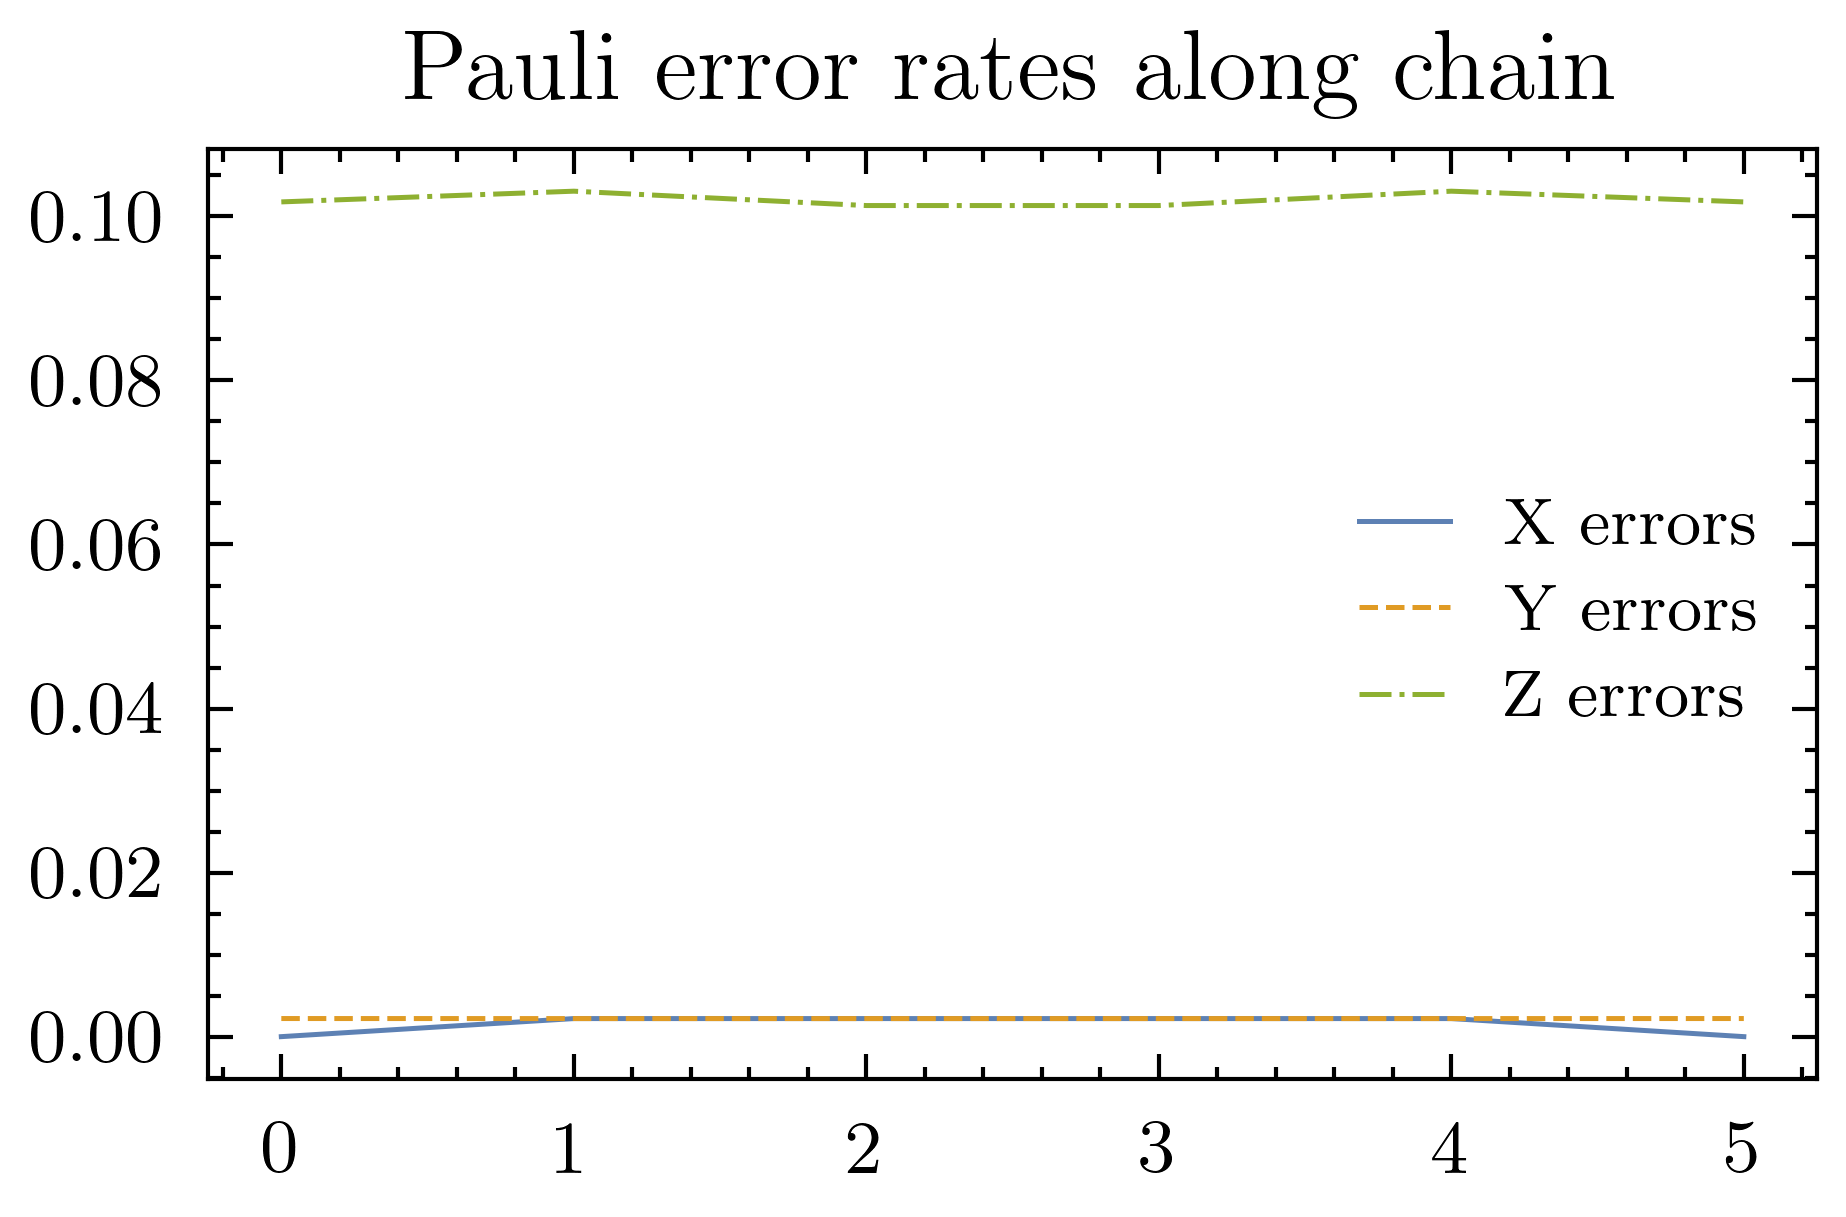

In [220]:
error_mat = return_errors(0.2, 0.9, 0.8, 3, n=6)
plt.plot(error_mat[:,0], label='X errors')
plt.plot(error_mat[:,1], label='Y errors')
plt.plot(error_mat[:,2], label='Z errors')
plt.title('Pauli error rates along chain')
plt.legend()
# plt.plot(stabval)
# error_mat

In [500]:
ζ_m_list = np.logspace(-5, np.log10(0.3), num=40)

err_list_id = []
err_list_1_99 = []
err_list_1_95 = []
err_list_1_9 = []
err_list_2_99 = []
err_list_2_95 = []
err_list_2_9 = []

for i in ζ_m_list:
    ζ = 1 - i
    err_mat = return_errors(0, 1, ζ, 3, n=6)
    err_list_id.append(err_mat[3,2])
    err_mat = return_errors(0.1, 0.99, ζ, 3, n=6)
    err_list_1_99.append(err_mat[3,2])
    err_mat = return_errors(0.1, 0.95, ζ, 3, n=6)
    err_list_1_95.append(err_mat[3,2])
    err_mat = return_errors(0.1, 0.9, ζ, 3, n=6)
    err_list_1_9.append(err_mat[3,2])
    err_mat = return_errors(0.2, 0.99, ζ, 3, n=6)
    err_list_2_99.append(err_mat[3,2])
    err_mat = return_errors(0.2, 0.95, ζ, 3, n=6)
    err_list_2_95.append(err_mat[3,2])
    err_mat = return_errors(0.2, 0.9, ζ, 3, n=6)
    err_list_2_9.append(err_mat[3,2])

In [501]:
#no errors slope 
coeff_id = np.polyfit(np.log10(ζ_m_list), np.log10(err_list_id), 1)
coeff_id[0]

np.float64(0.999999999999953)

Text(0.5, 1.1, 'Pauli Error Rates for a 3 Level System')

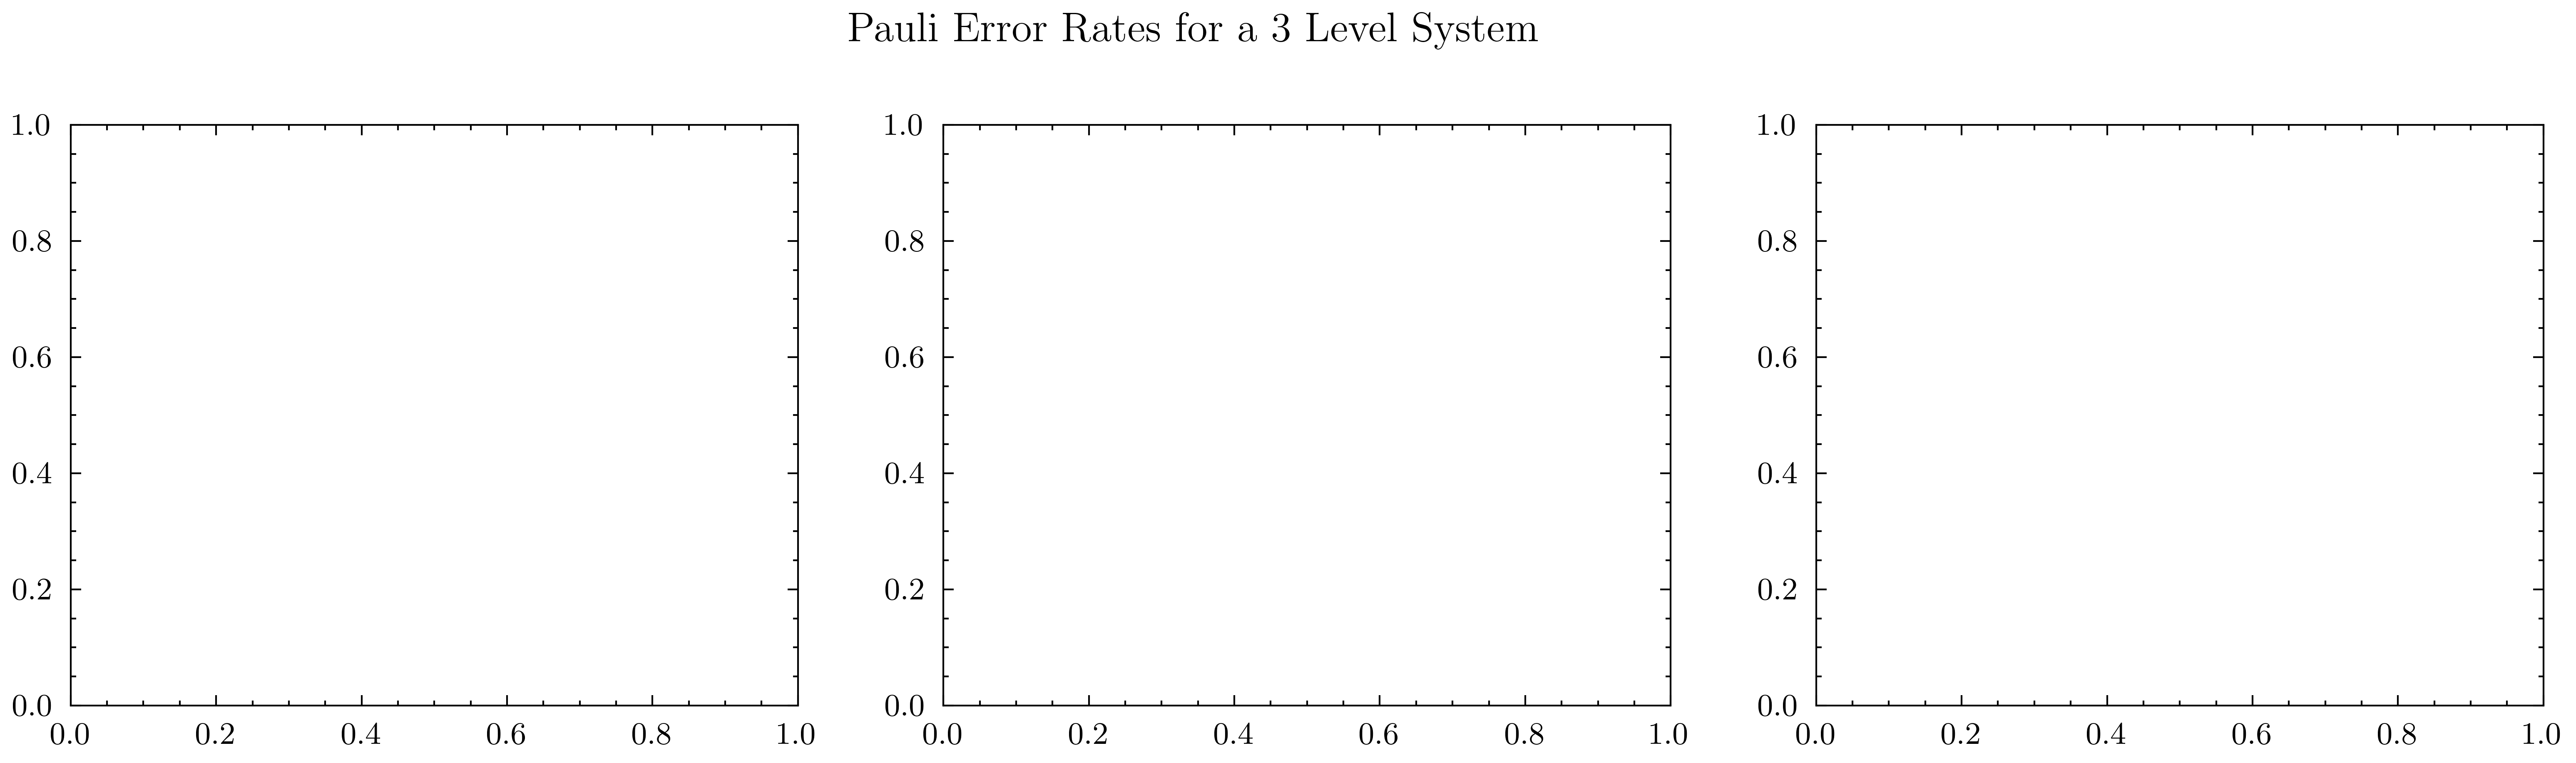

In [502]:
fig, p = plt.subplots(1,3, figsize=(12,3))
fig.suptitle('Pauli Error Rates for a 3 Level System', y=1.1)

In [503]:
p[0].loglog(ζ_m_list,err_list_id, label='Ideal $\gamma, \eta$', color='red', linestyle=':', alpha=0.5)
p[0].loglog([],[], label=f'slope = {coeff_id[0]:.2f}', alpha=0)
p[0].loglog(ζ_m_list, err_list_1_99, label='$\gamma$=0.1, $\eta$=0.99', linestyle='-', color='xkcd:blue')
p[0].loglog(ζ_m_list, err_list_1_95, label='$\gamma$=0.1, $\eta$=0.95', linestyle='--', color='xkcd:bright blue')
p[0].loglog(ζ_m_list, err_list_1_9, label='$\gamma$=0.1, $\eta$=0.9', linestyle='-.', color='xkcd:azure')
p[0].loglog(ζ_m_list, err_list_2_99, label='$\gamma$=0.2, $\eta$=0.99', color='xkcd:emerald', linestyle='-')
p[0].loglog(ζ_m_list, err_list_2_95, label='$\gamma$=0.2, $\eta$=0.95', color='xkcd:green', linestyle='--')
p[0].loglog(ζ_m_list, err_list_2_9, label='$\gamma$=0.2, $\eta$=0.9', color='xkcd:apple green', linestyle='-.')
p[0].set_xlabel('1 - $\zeta$')
p[0].set_ylabel('Error Rate')
p[0].set_title(r'$\hat{Z}$ error vs. $\zeta$')
# p.legend(loc='outer right')
p[0].legend( frameon=False,  prop={'size': 6}, loc='lower right')
# plt.show()
# fig.savefig('Stab3_pz_vs_zeta.png', bbox_inches='tight')

The X/Y errors are exacty the same, barring X being zero at the edges of the chain, and is independent of $\zeta$.

In [504]:
η_m_list = np.logspace(-5, np.log10(0.3), num=40)

err_list_id = []
err_list_1_95 = []
err_list_15_95 = []
err_list_2_95 = []


for i in η_m_list:
    η = 1 - i
    err_mat = return_errors(0, η, 0.95, 3, n=6)
    err_list_id.append(err_mat[3,0])
    err_mat = return_errors(0.1, η, 0.95, 3, n=6)
    err_list_1_95.append(err_mat[3,0])
    err_mat = return_errors(0.15, η, 0.95, 3, n=6)
    err_list_15_95.append(err_mat[3,0])
    err_mat = return_errors(0.2, η, 0.95, 3, n=6)
    err_list_2_95.append(err_mat[3,0])

In [505]:
# Take logarithm of both x and y data
log_x = np.log10(η_m_list)
log_1_95 = np.log10(err_list_1_95)
log_15_95 = np.log10(err_list_15_95)
log_2_95 = np.log10(err_list_2_95)

# Fit a line to the log-log data
coeff_1 = np.polyfit(log_x, log_1_95, 1)
coeff_15 = np.polyfit(log_x, log_15_95, 1)
coeff_2 = np.polyfit(log_x, log_2_95, 1)

# Generate fitted line
x_fit = η_m_list
y_fit_1 = 10**(coeff_1[0] * np.log10(x_fit) + coeff_1[1])
y_fit_15 = 10**(coeff_15[0] * np.log10(x_fit) + coeff_15[1])
y_fit_2 = 10**(coeff_2[0] * np.log10(x_fit) + coeff_2[1])

In [506]:
# fig, p = plt.subplots(1,1)
# p.plot(η_m_list,err_list_id, label='No errors', color='xkcd:deep blue', linestyle=':')

p[1].loglog(η_m_list, err_list_1_95, label='$\gamma$=0.1, $\zeta$=0.95', linestyle='-', color='xkcd:blue')
p[1].loglog(η_m_list, err_list_15_95, label='$\gamma$=0.15, $\zeta$=0.95', linestyle='--', color='xkcd:bright blue')
p[1].loglog(η_m_list, err_list_2_95, label='$\gamma$=0.2, $\zeta$=0.95', color='xkcd:azure', linestyle='-.')

p[1].loglog([], [], label=f'slope = {coeff_1[0]:.2f}', alpha=0)


p[1].set_xlabel('1 - $\eta$')
# p[1].set_ylabel('Error Rate')
p[1].set_title(r'$\hat{X}/\hat{Y}$ error vs. $\eta$')
# p.legend(loc='outer right')
p[1].legend( frameon=False,  prop={'size': 7}, loc='lower right')
# plt.show()

In [507]:
η_m_list = np.logspace(-5, np.log10(0.3), num=40)

err_list_id = []
err_list_1_1 = []
err_list_15_1 = []
# err_list_2_1 = []
err_list_0_99 = []
err_list_1_99 = []
err_list_15_99 = []
# err_list_2_99 = []


for i in η_m_list:
    η = 1 - i
    err_mat = return_errors(0, η, 1, 3, n=6)
    err_list_id.append(err_mat[3,2])
    err_mat = return_errors(0.1, η, 1, 3, n=6)
    err_list_1_1.append(err_mat[3,2])
    err_mat = return_errors(0.15, η, 1, 3, n=6)
    err_list_15_1.append(err_mat[3,2])
    err_mat = return_errors(0, η, 0.99, 3, n=6)
    err_list_0_99.append(err_mat[3,2])
    err_mat = return_errors(0.1, η, 0.99, 3, n=6)
    err_list_1_99.append(err_mat[3,2])
    err_mat = return_errors(0.15, η, 0.99, 3, n=6)
    err_list_15_99.append(err_mat[3,2])

In [508]:
# fig, p2 = plt.subplots(1,1)
p[2].plot(ζ_m_list,err_list_id, label='Ideal $\gamma$, $\zeta$', color='red', linestyle=':', alpha=0.5)
p[2].plot(ζ_m_list, err_list_1_1, label='$\gamma$=0.1, $\zeta$=1', linestyle='--', color='xkcd:blue')
p[2].plot(ζ_m_list, err_list_15_1, label='$\gamma$=0.15, $\zeta$=1', linestyle='-.', color='xkcd:bright blue')
# p[2].plot(ζ_m_list, err_list_2_1, label='$\gamma$=0.2, $\eta$=0.99', linestyle='--', color='xkcd:azure')
p[2].plot(ζ_m_list, err_list_0_99, label='$\gamma$=0, $\zeta$=0.99', color='xkcd:emerald', linestyle='-')
p[2].plot(ζ_m_list, err_list_1_99, label='$\gamma$=0.1, $\zeta$=0.99', color='xkcd:green', linestyle='--')
p[2].plot(ζ_m_list, err_list_15_99, label='$\gamma$=0.15, $\zeta$=0.99', color='xkcd:apple green', linestyle='-.')
# p[2].plot(ζ_m_list, err_list_2_99, label='$\gamma$=0.2, $\eta$=0.99', color='xkcd:lime green', linestyle='-')
p[2].set_xlabel('1 - $\eta$')
# p[2].set_ylabel('Error Rate')
p[2].set_title(r'$\hat{Z}$ error vs. $\eta$')
# p.set_yscale('log')
# p.set_xscale('log')
p[2].legend(frameon=False,  prop={'size': 7}, loc='upper left')
# plt.show()

# fig.legend()

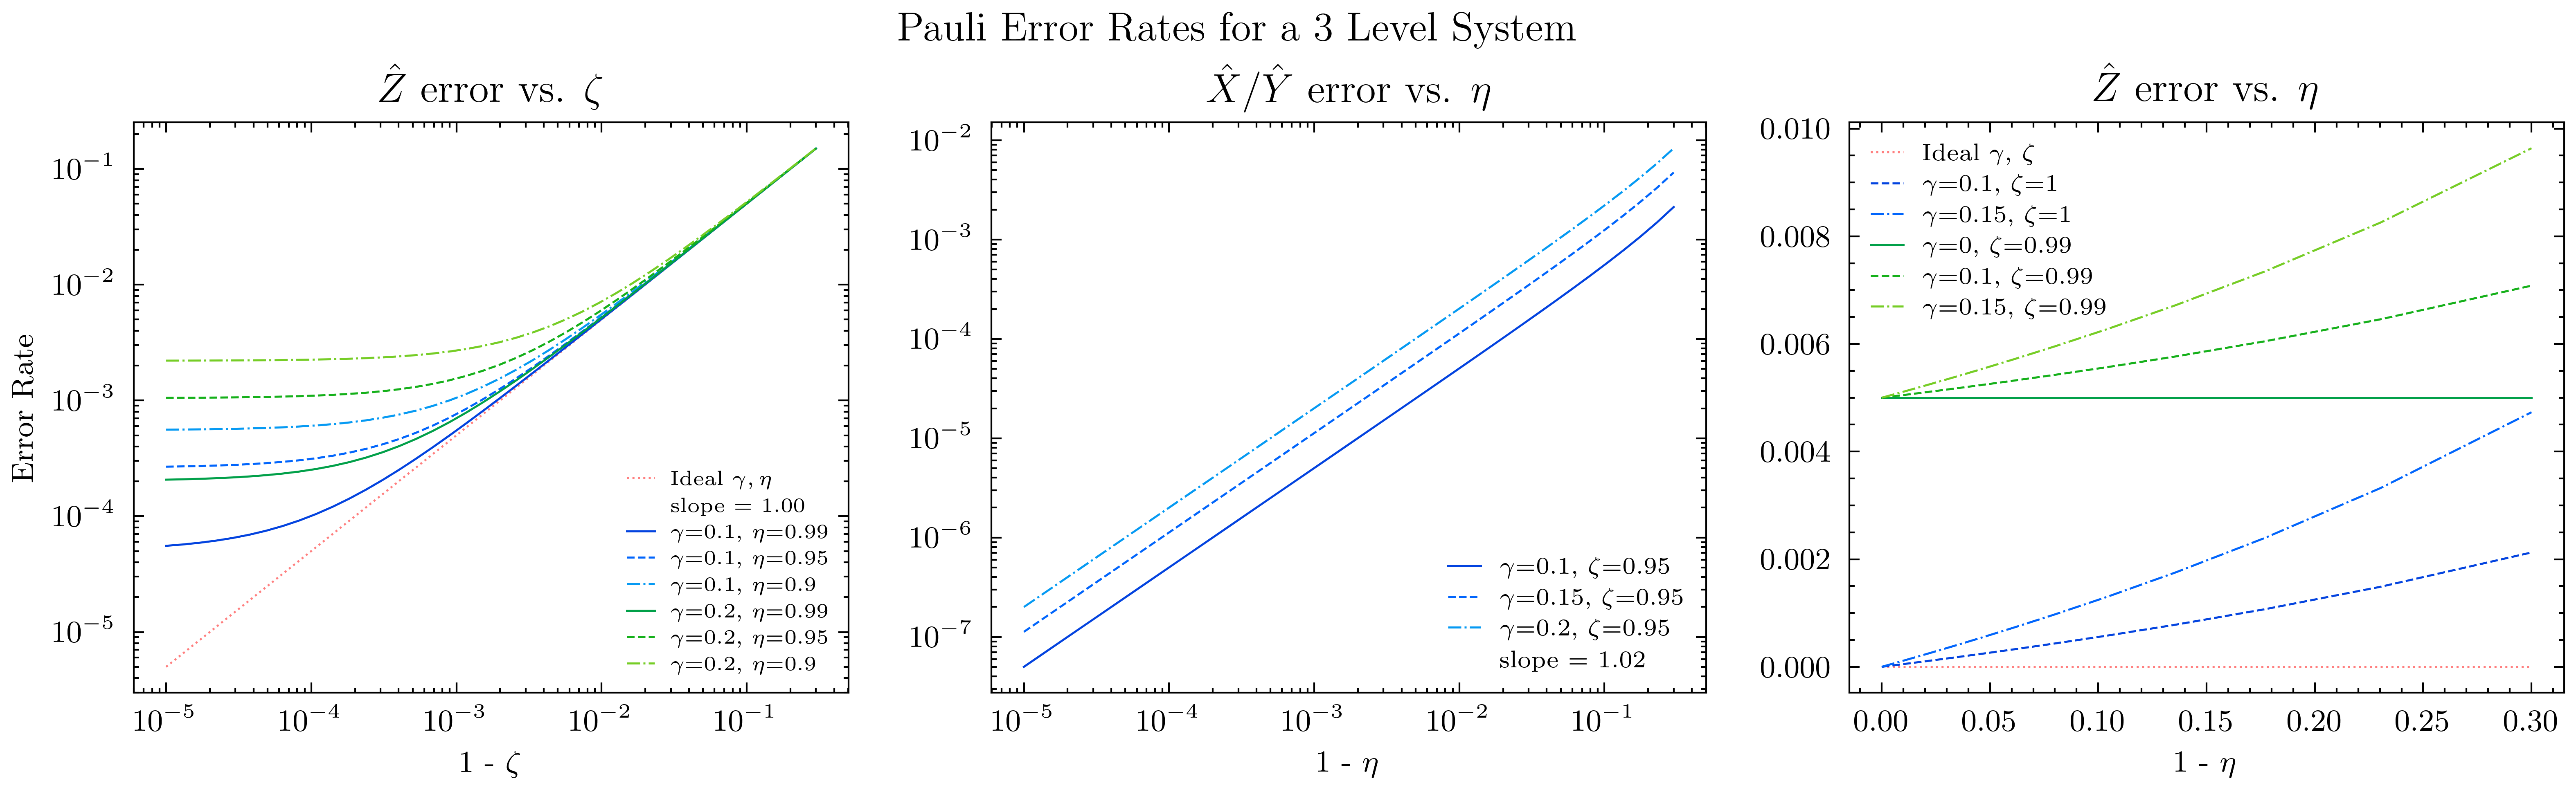

In [509]:
fig


In [510]:
fig.savefig('Stab3.pdf', bbox_inches='tight')

## 4 Level

Only has pauli X errors along chain.

array([[ 2.01238380e-01,  2.21238938e-04,  2.21238938e-04],
       [ 2.01195190e-01,  2.21287906e-04,  0.00000000e+00],
       [ 2.01106195e-01,  2.21238938e-04,  2.21238938e-04],
       [ 2.01195161e-01,  1.32273059e-04, -1.32273059e-04],
       [ 2.01591746e-01,  4.42477876e-04,  0.00000000e+00],
       [ 2.00752878e-01,  5.74555148e-04,  3.10009031e-04]])

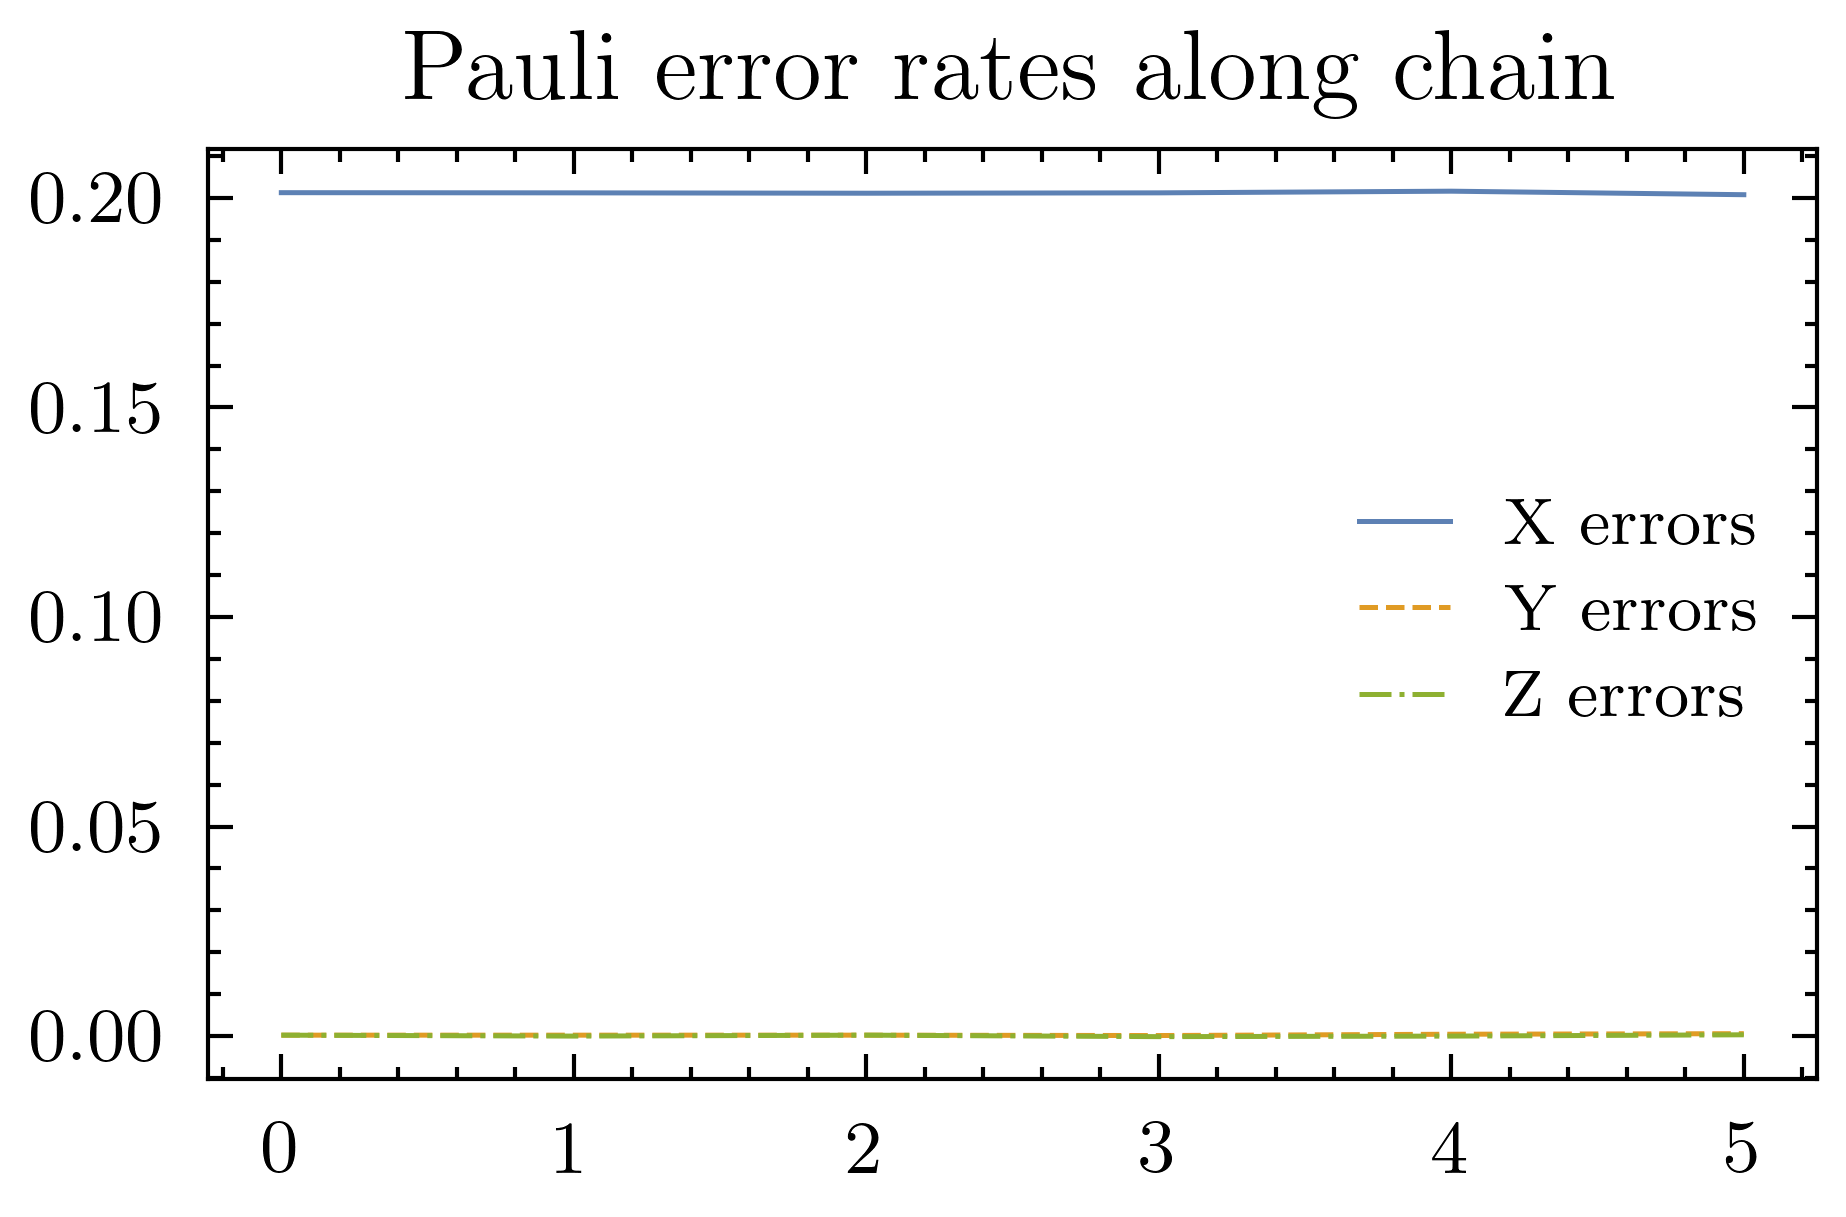

In [511]:
error_mat = return_errors(0.2, 0.9, 0.8, 4, bound_cond='Z', n=6)
plt.plot(error_mat[:,0], label='X errors')
plt.plot(error_mat[:,1], label='Y errors')
plt.plot(error_mat[:,2], label='Z errors')
plt.title('Pauli error rates along chain')
plt.legend()
# plt.plot(stabval)
error_mat

Text(0.5, 1.1, 'Pauli Error Rates for a 4 Level System')

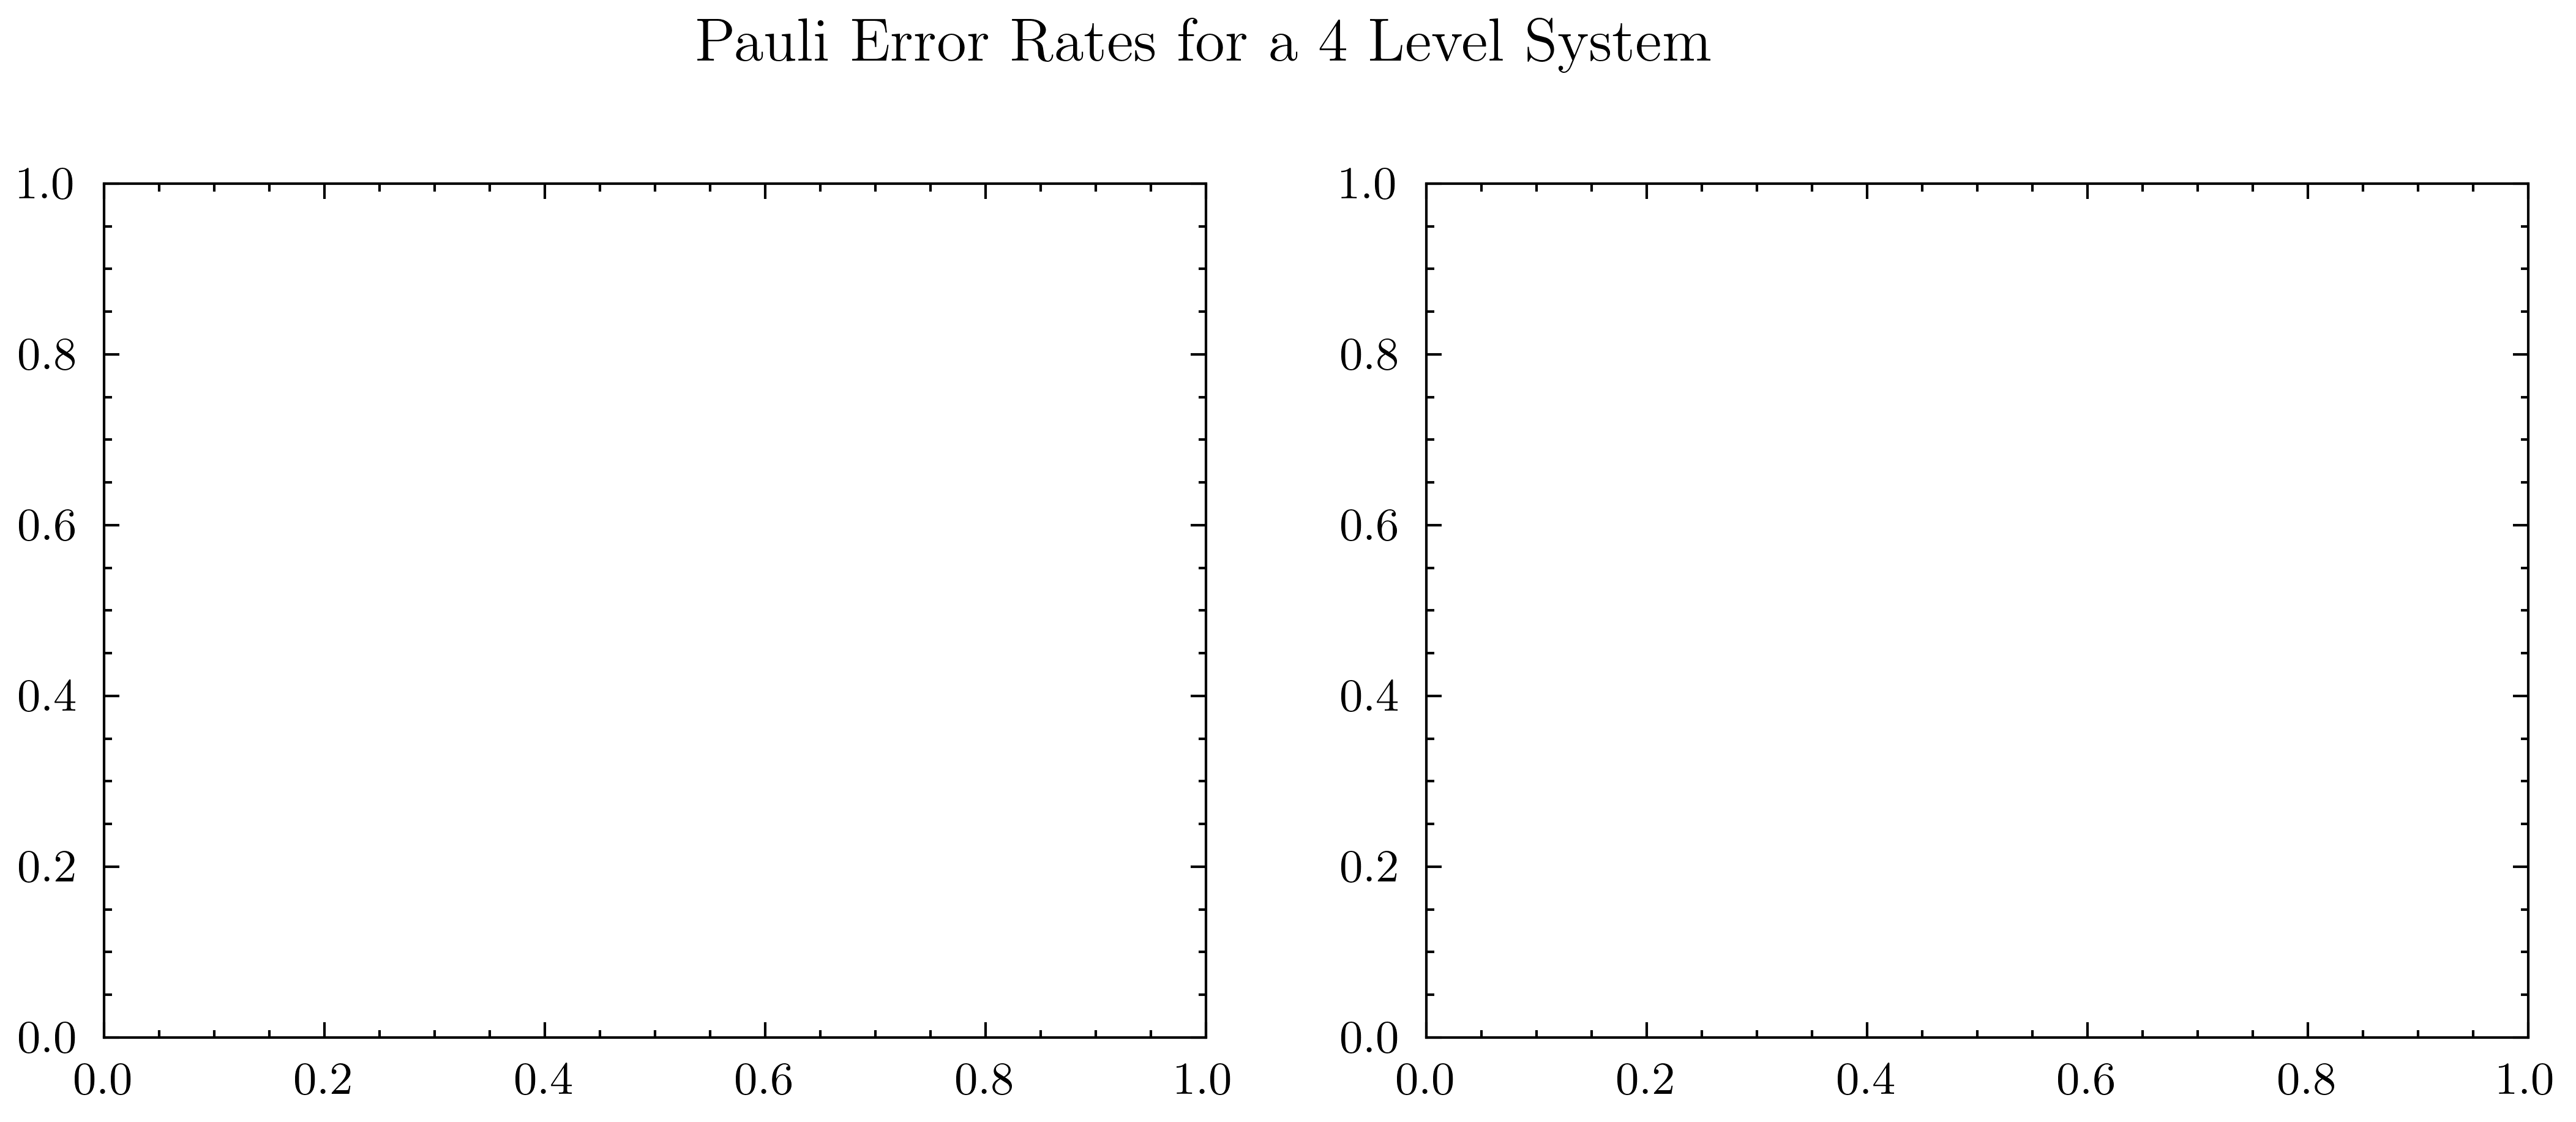

In [512]:
fig, p = plt.subplots(1,2, figsize=(8,3))
fig.suptitle('Pauli Error Rates for a 4 Level System', y=1.1)

In [513]:
D_m_list = np.logspace(-5, np.log10(0.3), num=40)

err_list_id = []
err_list_0_99 = []
err_list_1_99 = []
err_list_15_99 = []
err_list_2_99 = []

for i in D_m_list:
    D = 1 - i
    err_mat = return_errors(0, 1, D, 4, bound_cond='Z', n=6)
    err_list_id.append(err_mat[3,0])
    err_mat = return_errors(0, 0.99, D, 4, bound_cond='Z', n=6)
    err_list_0_99.append(err_mat[3,0])
    err_mat = return_errors(0.1, 0.99, D, 4, bound_cond='Z', n=6)
    err_list_1_99.append(err_mat[3,0])
    err_mat = return_errors(0.15, 0.99, D, 4, bound_cond='Z', n=6)
    err_list_15_99.append(err_mat[3,0])
    err_mat = return_errors(0.2, 0.99, D , 4, bound_cond='Z', n=6)
    err_list_2_99.append(err_mat[3,0])

In [514]:
coeff_id = np.polyfit(np.log10(D_m_list), np.log10(err_list_id), 1)
coeff_id[0]

np.float64(0.9999999999999956)

In [515]:
p[0].loglog(D_m_list,err_list_id, label='Ideal $\gamma, \eta$', color='red', linestyle=':', alpha=0.5)
p[0].plot([],[], label=f'slope = {coeff_id[0]:.2f}', alpha=0)
p[0].loglog(D_m_list, err_list_0_99, label='$\gamma$=0, $\eta$=0.99', linestyle='', marker='x', ms=2, alpha=0.5, color='xkcd:red')
p[0].loglog(D_m_list, err_list_1_99, label='$\gamma$=0.1, $\eta$=0.99', linestyle='-', color='xkcd:deep blue')
p[0].loglog(D_m_list, err_list_15_99, label='$\gamma$=0.15, $\eta$=0.99', linestyle='--', color='xkcd:blue')
p[0].loglog(D_m_list, err_list_2_99, label='$\gamma$=0.2, $\eta$=0.99', color='xkcd:sky blue', linestyle='-.')
p[0].set_xlabel('1 - $\mathcal{D}$')
p[0].set_ylabel('Error Rate')
p[0].set_title(r'$\hat{X}$ error vs. $\mathcal{D}$')
p[0].legend( frameon=False,  prop={'size': 6})


In [516]:
η_m_list = np.linspace(0, 0.3, num=40)

err_list_0_95 = []
err_list_1_95 = []
err_list_15_95 = []
err_list_2_95 = []


for i in η_m_list:
    η = 1 - i
    err_mat = return_errors(0, η, 0.95, 4, bound_cond='Z', n=6)
    err_list_0_95.append(err_mat[3,0])
    err_mat = return_errors(0.1, η, 0.95, 4, bound_cond='Z', n=6)
    err_list_1_95.append(err_mat[3,0])
    err_mat = return_errors(0.15, η, 0.95, 4, bound_cond='Z', n=6)
    err_list_15_95.append(err_mat[3,0])
    err_mat = return_errors(0.2, η, 0.95, 4, bound_cond='Z', n=6)
    err_list_2_95.append(err_mat[3,0])

In [517]:
# coeff = np.polyfit(np.log10(η_m_list), np.log10(err_list_0_95), 1)
# coeff[0]

In [518]:
############################################
#Differences in Y scale too small for log-log
############################################

# p.plot(η_m_list,err_list_id, label='Ideal $\gamma, \eta$', color='red', linestyle=':', alpha=0.5)
# p.plot([],[], label=f'slope = {coeff_id[0]:.2f}', alpha=0)
p[1].plot(η_m_list, err_list_0_95, label='$\gamma$=0, $\zeta$=0.95', linestyle='-', color='xkcd:deep blue')
p[1].plot(η_m_list, err_list_1_95, label='$\gamma$=0.1, $\zeta$=0.95', linestyle='--', color='xkcd:blue')
p[1].plot(η_m_list, err_list_15_95, label='$\gamma$=0.15, $\zeta$=0.95', linestyle='-.', color='xkcd:azure')
p[1].plot(η_m_list, err_list_2_95, label='$\gamma$=0.2, $\zeta$=0.95', color='xkcd:sky blue', linestyle=':')
# p[1].set_yscale('log')
# p[1].set_xscale('log')
p[1].set_xlabel('1 - $\eta$')
# p[1].set_ylabel('Error Rate')
p[1].set_title(r'$\hat{X}$ error vs. $\eta$')
# p.legend(loc='outer right')
p[1].legend( frameon=False,  prop={'size': 6})

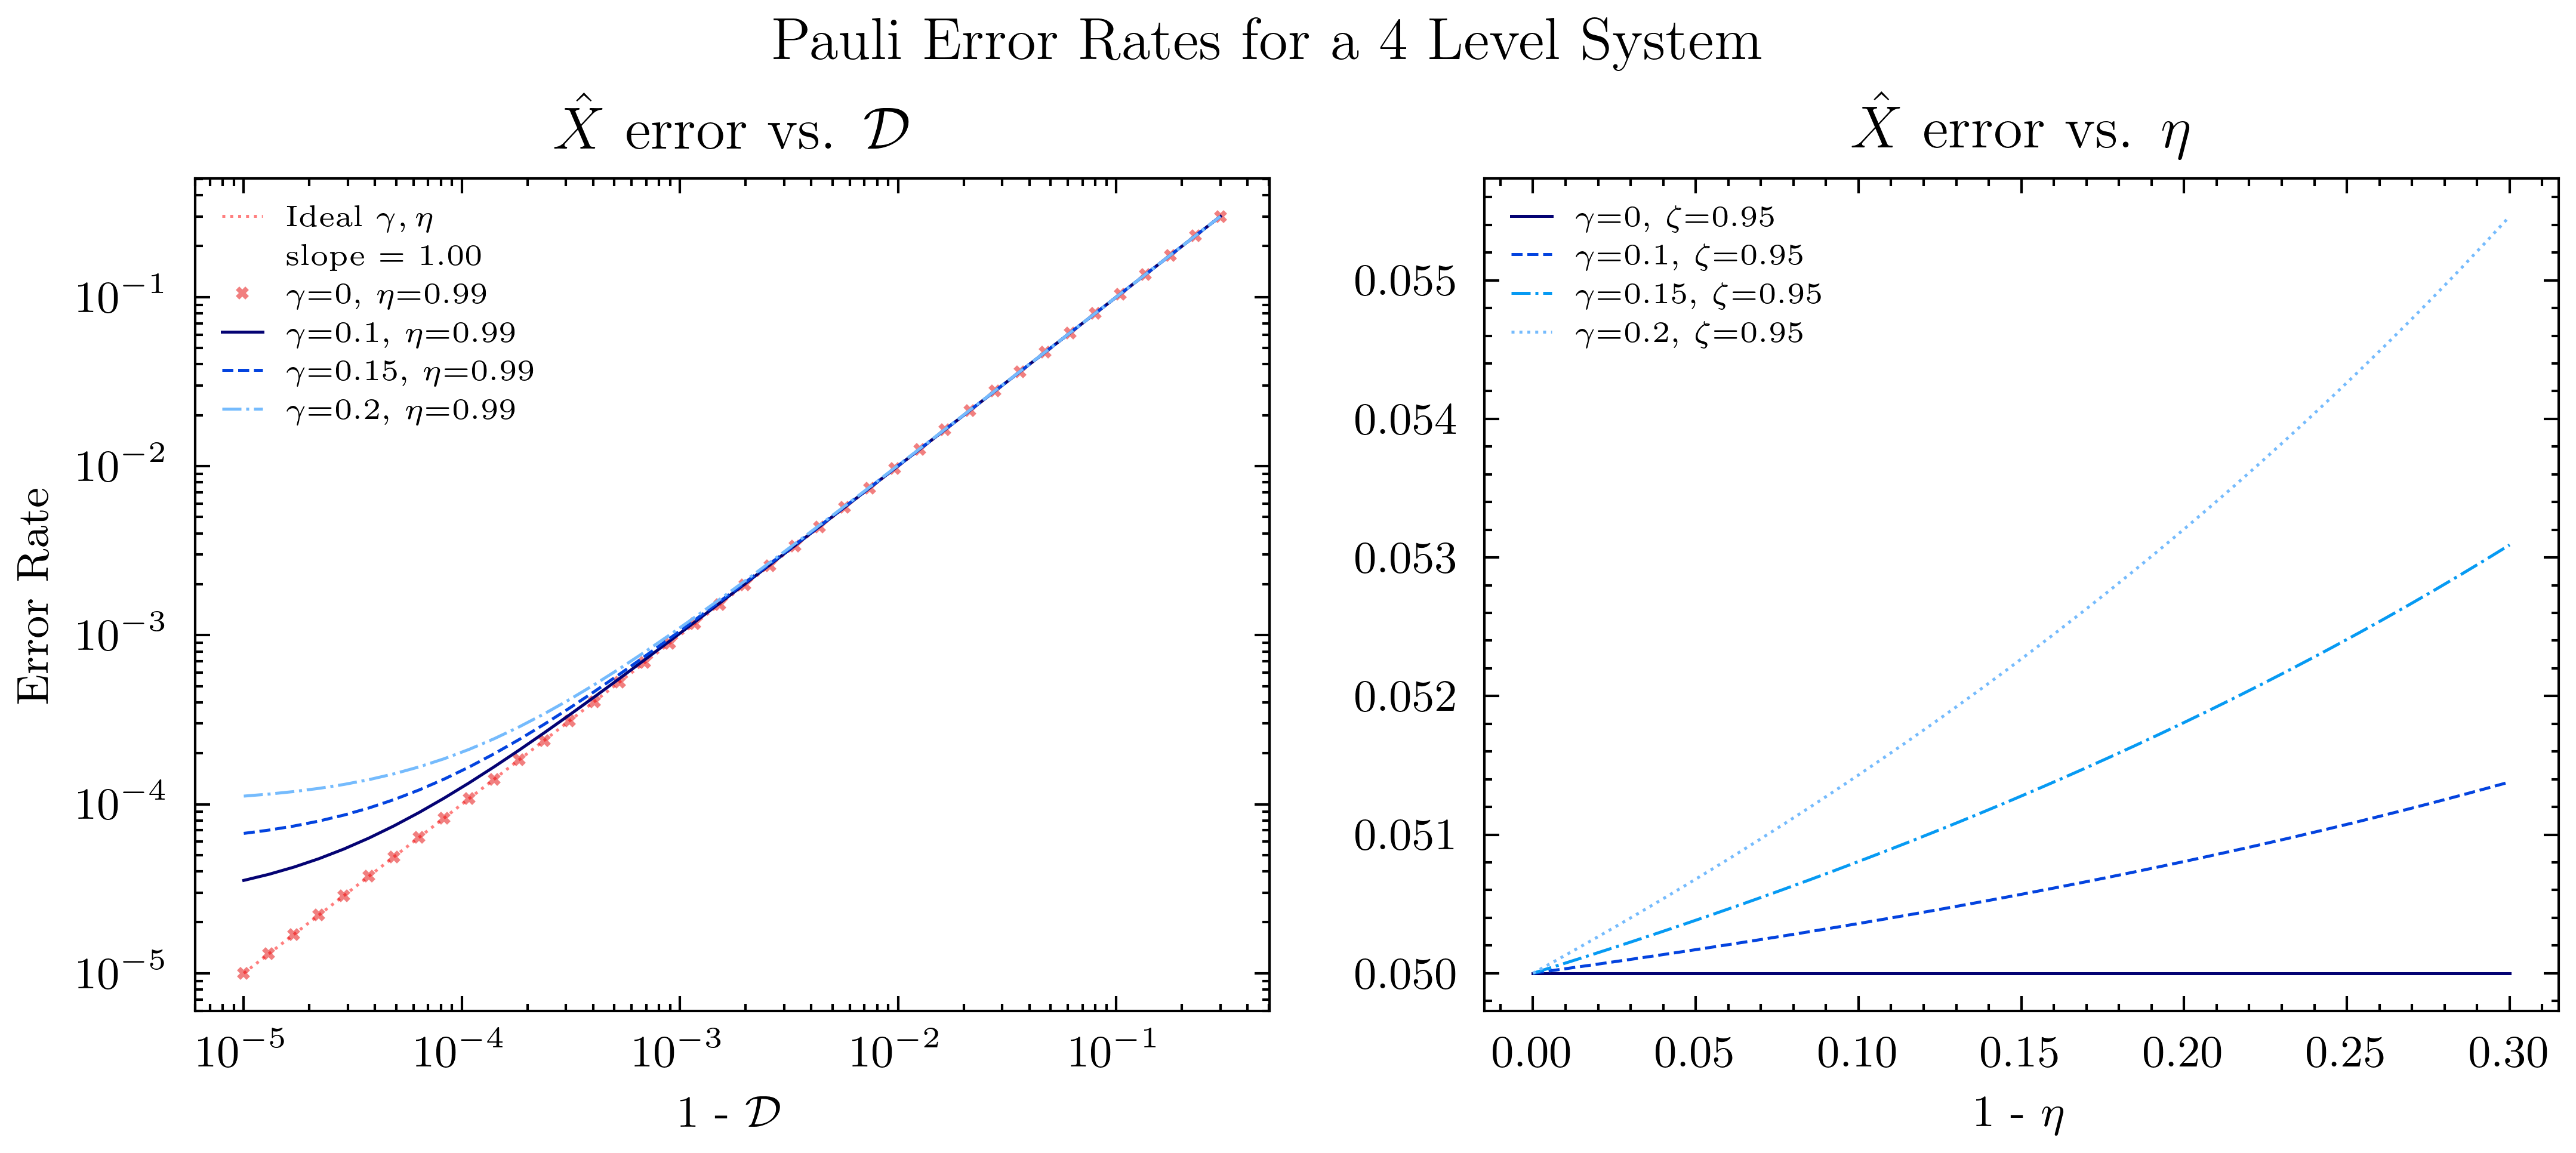

In [519]:
fig

In [520]:
fig.savefig('Stab4.pdf', bbox_inches='tight')

# Fusion

## 3 Level

Only Z is affected by $\zeta$ <br>
All affected by $\eta$, $\gamma$

In [645]:
sum(pauli_err_fusion3(0.1, 0.99, 0.95))

np.float64(1.0)

Text(0.5, 1.1, 'Pauli Error Rates for Fusion Operation (3 Level)')

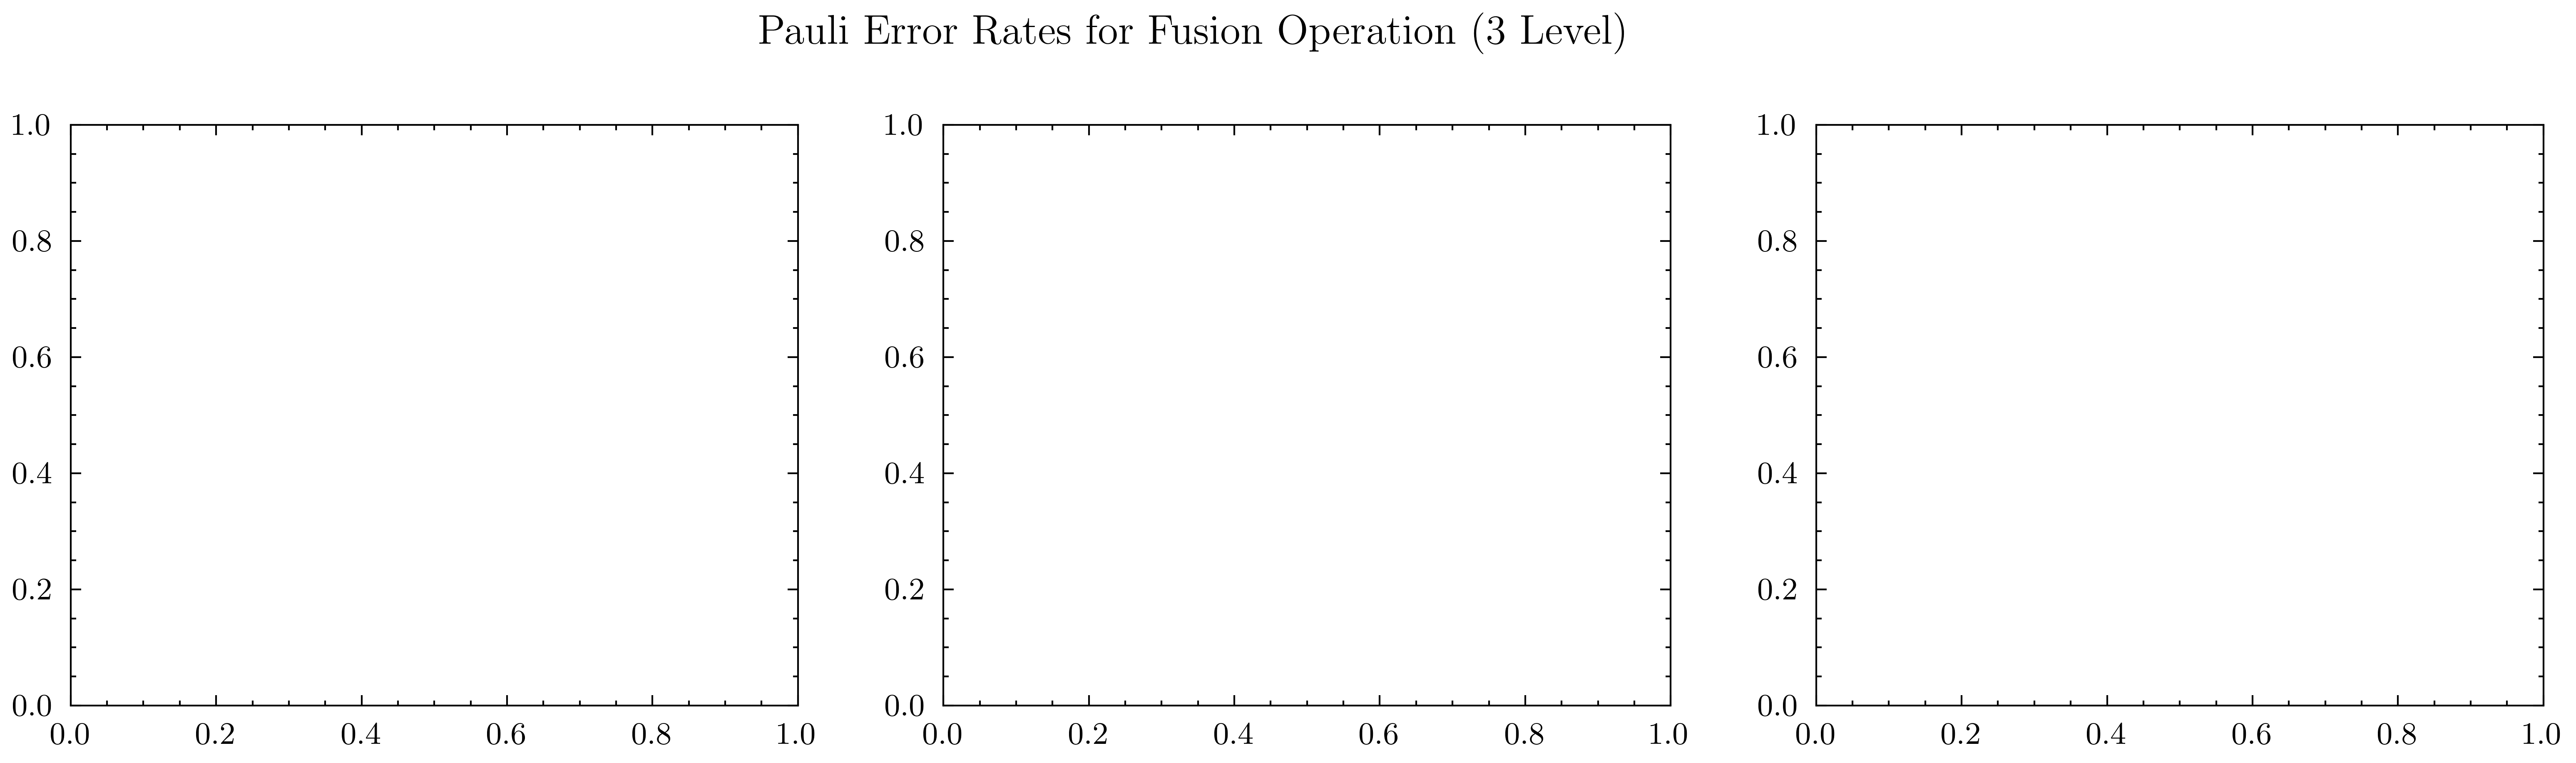

In [646]:
fig, p = plt.subplots(1,3, figsize=(12,3))
fig.suptitle('Pauli Error Rates for Fusion Operation (3 Level)', y=1.1)

$\gamma$ 0 or $\eta$ 1 is same as ideal

In [647]:
ζ_m_list = np.logspace(-5, np.log10(0.3), num=40)

err_list_id = []
err_list_1_1 = []
err_list_1_99 = []
err_list_1_95 = []
err_list_1_9 = []

for i in ζ_m_list:
    ζ = 1 - i
    err_mat = pauli_err_fusion3(0, 1, ζ)
    err_list_id.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.1, 1, ζ)
    err_list_1_1.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.1, 0.99, ζ)
    err_list_1_99.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.1, 0.95, ζ)
    err_list_1_95.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.1, 0.9, ζ)
    err_list_1_9.append(err_mat[2])

In [648]:
#no errors slope 
coeff_id = np.polyfit(np.log10(ζ_m_list), np.log10(err_list_id), 1)
coeff_id[0]

/var/folders/s9/whvhj6gs5cx001kw71n2wfqr0000gq/T/ipykernel_48718/2216787811.py:2: RuntimeWarning: divide by zero encountered in log10
  coeff_id = np.polyfit(np.log10(ζ_m_list), np.log10(err_list_id), 1)
/var/folders/s9/whvhj6gs5cx001kw71n2wfqr0000gq/T/ipykernel_48718/2216787811.py:2: RuntimeWarning: invalid value encountered in log10
  coeff_id = np.polyfit(np.log10(ζ_m_list), np.log10(err_list_id), 1)


np.float64(nan)

In [649]:

p[0].loglog(ζ_m_list[::2] ,err_list_id[::2], label='Ideal $\gamma, \zeta$', color='red', linestyle='', alpha=0.4, marker='x', ms=3)
p[0].loglog([],[], label=f'slope = {coeff_id[0]:.2f}', alpha=0)
p[0].loglog(ζ_m_list, err_list_1_1, label='$\gamma$=0.1, $\eta$=1', linestyle='-', color='xkcd:blue')
p[0].loglog(ζ_m_list, err_list_1_99, label='$\gamma$=0.1, $\eta$=0.99', linestyle='--', color='xkcd:bright blue')
p[0].loglog(ζ_m_list, err_list_1_95, label='$\gamma$=0.1, $\eta$=0.95', linestyle='-.', color='xkcd:azure')
p[0].loglog(ζ_m_list, err_list_1_9, label='$\gamma$=0.1, $\eta$=0.9', linestyle=':', color='xkcd:baby blue')
p[0].legend( frameon=False,  prop={'size': 6}, loc='lower right')
# p.set_xscale('log')
# p.set_yscale('log')
p[0].set_xlabel('1 - $\zeta$')
p[0].set_ylabel('Error Rate')
p[0].set_title(r'$\hat{Z}$ error vs. $\zeta$')

Text(0.5, 1.0, '$\\hat{Z}$ error vs. $\\zeta$')

In [650]:
# η_m_list = np.logspace(-5, np.log10(0.3), num=40)
η_m_list = np.linspace(0, 0.3, num=40)

err_list_id = []
err_list_1_1 = []
err_list_2_1 = []
err_list_0_95 = []
err_list_1_95 = []
err_list_2_95 = []

for i in η_m_list:
    η = 1 - i
    err_mat = pauli_err_fusion3(0, η, 1)
    err_list_id.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.1, η, 1)
    err_list_1_1.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.2, η, 1)
    err_list_2_1.append(err_mat[2])
    err_mat = pauli_err_fusion3(0, η, 0.95)
    err_list_0_95.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.1, η, 0.95)
    err_list_1_95.append(err_mat[2])
    err_mat = pauli_err_fusion3(0.2, η, 0.95)
    err_list_2_95.append(err_mat[2])

In [651]:
p[1].plot(η_m_list,err_list_id, label='Ideal $\gamma, \zeta$', color='xkcd:blue', linestyle='-', alpha=0.5)
# p.loglog([],[], label=f'slope = {coeff_id[0]:.2f}', alpha=0)
p[1].plot(η_m_list, err_list_1_1, label='$\gamma$=0.1, $\zeta$=1', linestyle='--', color='xkcd:baby blue')
p[1].plot(η_m_list, err_list_2_1, label='$\gamma$=0.2, $\zeta$=1', linestyle='-.', color='xkcd:azure')
p[1].plot(η_m_list, err_list_0_95, label='$\gamma$=0, $\zeta$=0.95', linestyle='-', color='xkcd:emerald')
p[1].plot(η_m_list, err_list_1_95, label='$\gamma$=0.1, $\zeta$=0.95', linestyle='--', color='xkcd:green')
p[1].plot(η_m_list, err_list_2_95, label='$\gamma$=0.2, $\zeta$=0.95', color='xkcd:apple green', linestyle='-.')
# p.set_xscale('log')
# p.set_yscale('log')
p[1].legend(loc='upper right', frameon=False,  prop={'size': 6})
p[1].set_xlabel('1 - $\eta$')
# p[1].set_ylabel('Error Rate')  
p[1].set_title(r'$\hat{Z}$ error vs. $\eta$')

Text(0.5, 1.0, '$\\hat{Z}$ error vs. $\\eta$')

$\zeta$ doesnt affect X/Y, both roughly same

In [652]:
η_m_list = np.logspace(-5, np.log10(0.3), num=40)
# η_m_list = np.linspace(0, 0.3, num=40)

err_list_1_95 = []
err_list_15_95 = []
err_list_2_95 = []
# err_list_2_95y = []

for i in η_m_list:
    η = 1 - i
    err_mat = pauli_err_fusion3(0.15, η, 0.95)
    err_list_15_95.append(err_mat[1])
    err_mat = pauli_err_fusion3(0.1, η, 0.95)
    err_list_1_95.append(err_mat[1])
    err_mat = pauli_err_fusion3(0.2, η, 0.95)
    err_list_2_95.append(err_mat[1])
    # err_list_2_95y.append(err_mat[0])

In [653]:
coeff = np.polyfit(np.log10(η_m_list), np.log10(err_list_15_95), 1)
coeff[0]

np.float64(1.0111633522010532)

In [654]:
# fig, p = plt.subplots(1,1)
# p.plot(η_m_list,err_list_id, label='Ideal $\gamma, \zeta$', color='xkcd:blue', linestyle='-', alpha=0.5, marker='o')
p[2].loglog([],[], label=f'slope = {coeff[0]:.2f}', alpha=0)
p[2].loglog(η_m_list, err_list_1_95, label='$\gamma$=0.1, $\zeta$=0.95', linestyle='-', color='xkcd:blue')
p[2].loglog(η_m_list, err_list_15_95, label='$\gamma$=0.15, $\zeta$=0.95', linestyle='--', color='xkcd:bright blue')
p[2].loglog(η_m_list, err_list_2_95, label='$\gamma$=0.2, $\zeta$=0.95', color='xkcd:azure', linestyle='-.')
p[2].legend(loc='lower right', frameon=False,  prop={'size': 6})
p[2].set_xlabel('1 - $\eta$')
# p[2].set_ylabel('Error Rate')  
p[2].set_title(r'$\hat{X} / \hat{Y}$ error vs. $\eta$')

Text(0.5, 1.0, '$\\hat{X} / \\hat{Y}$ error vs. $\\eta$')

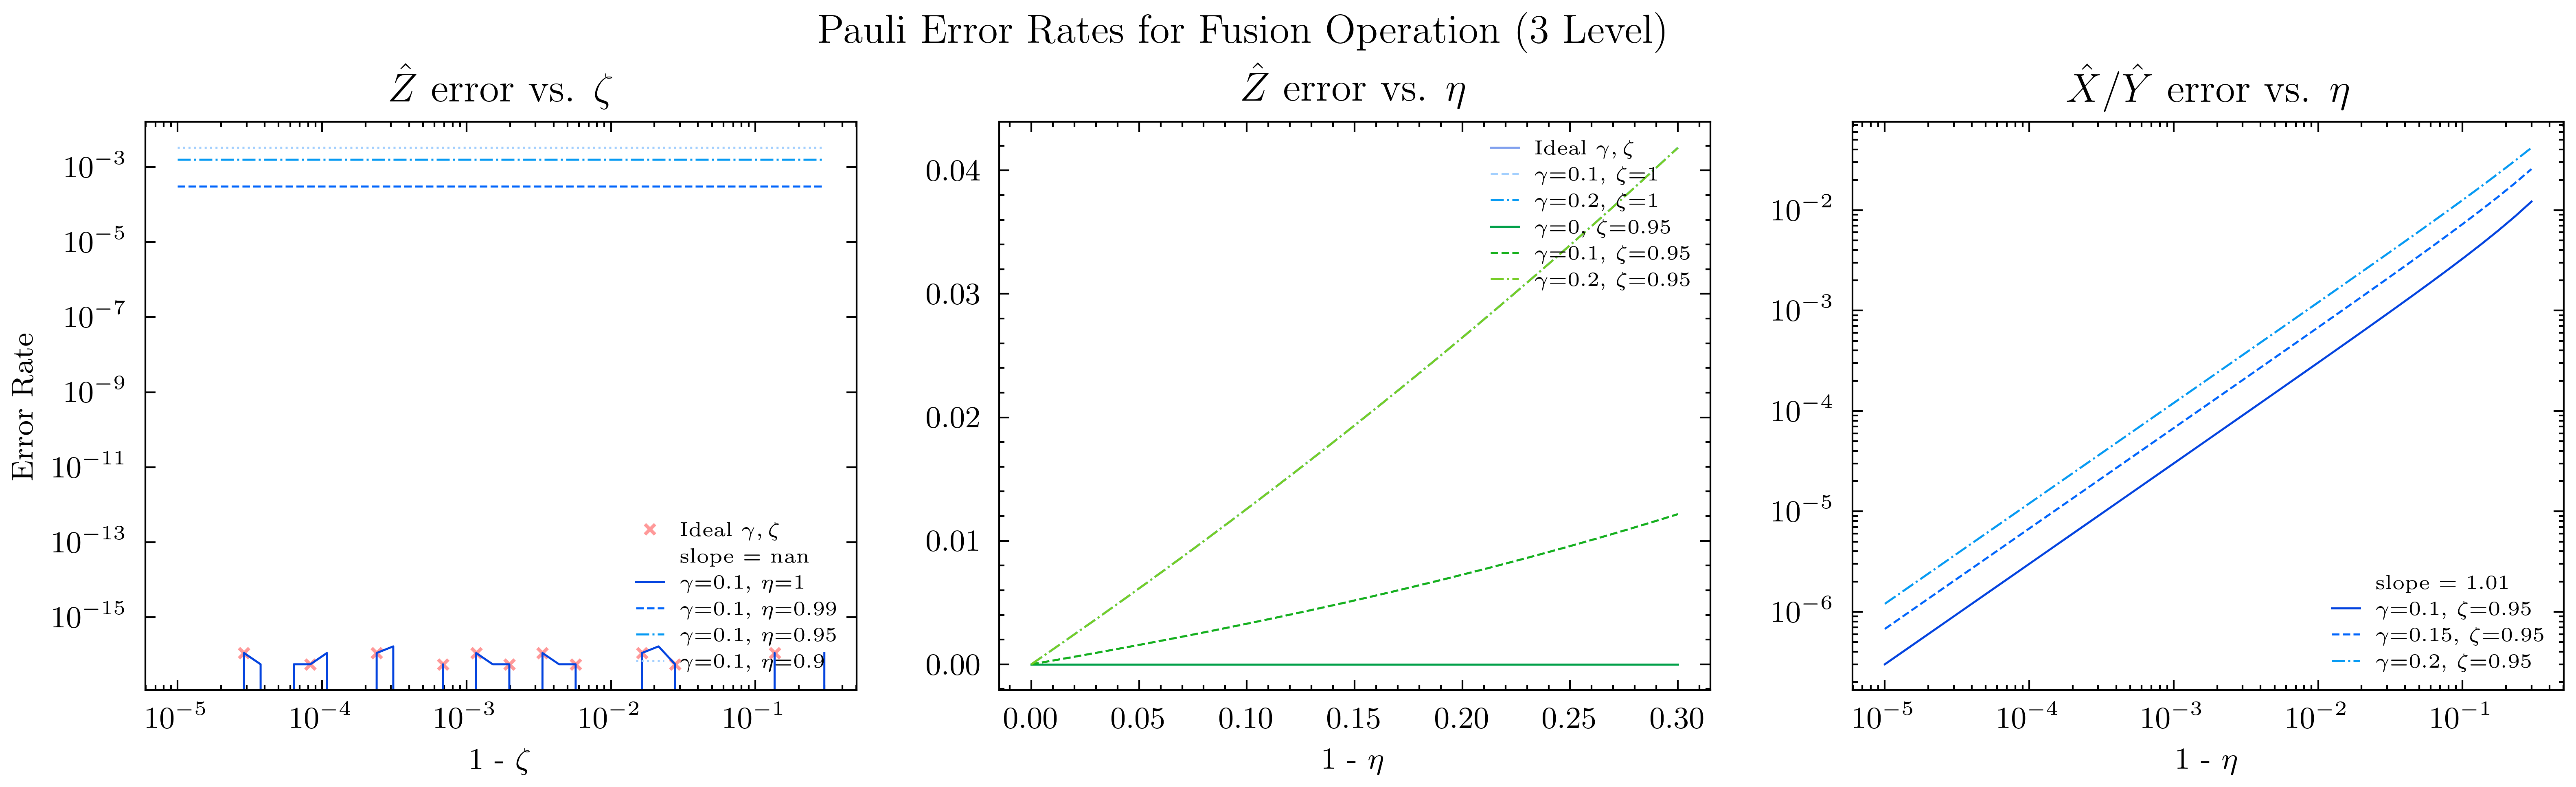

In [655]:
fig

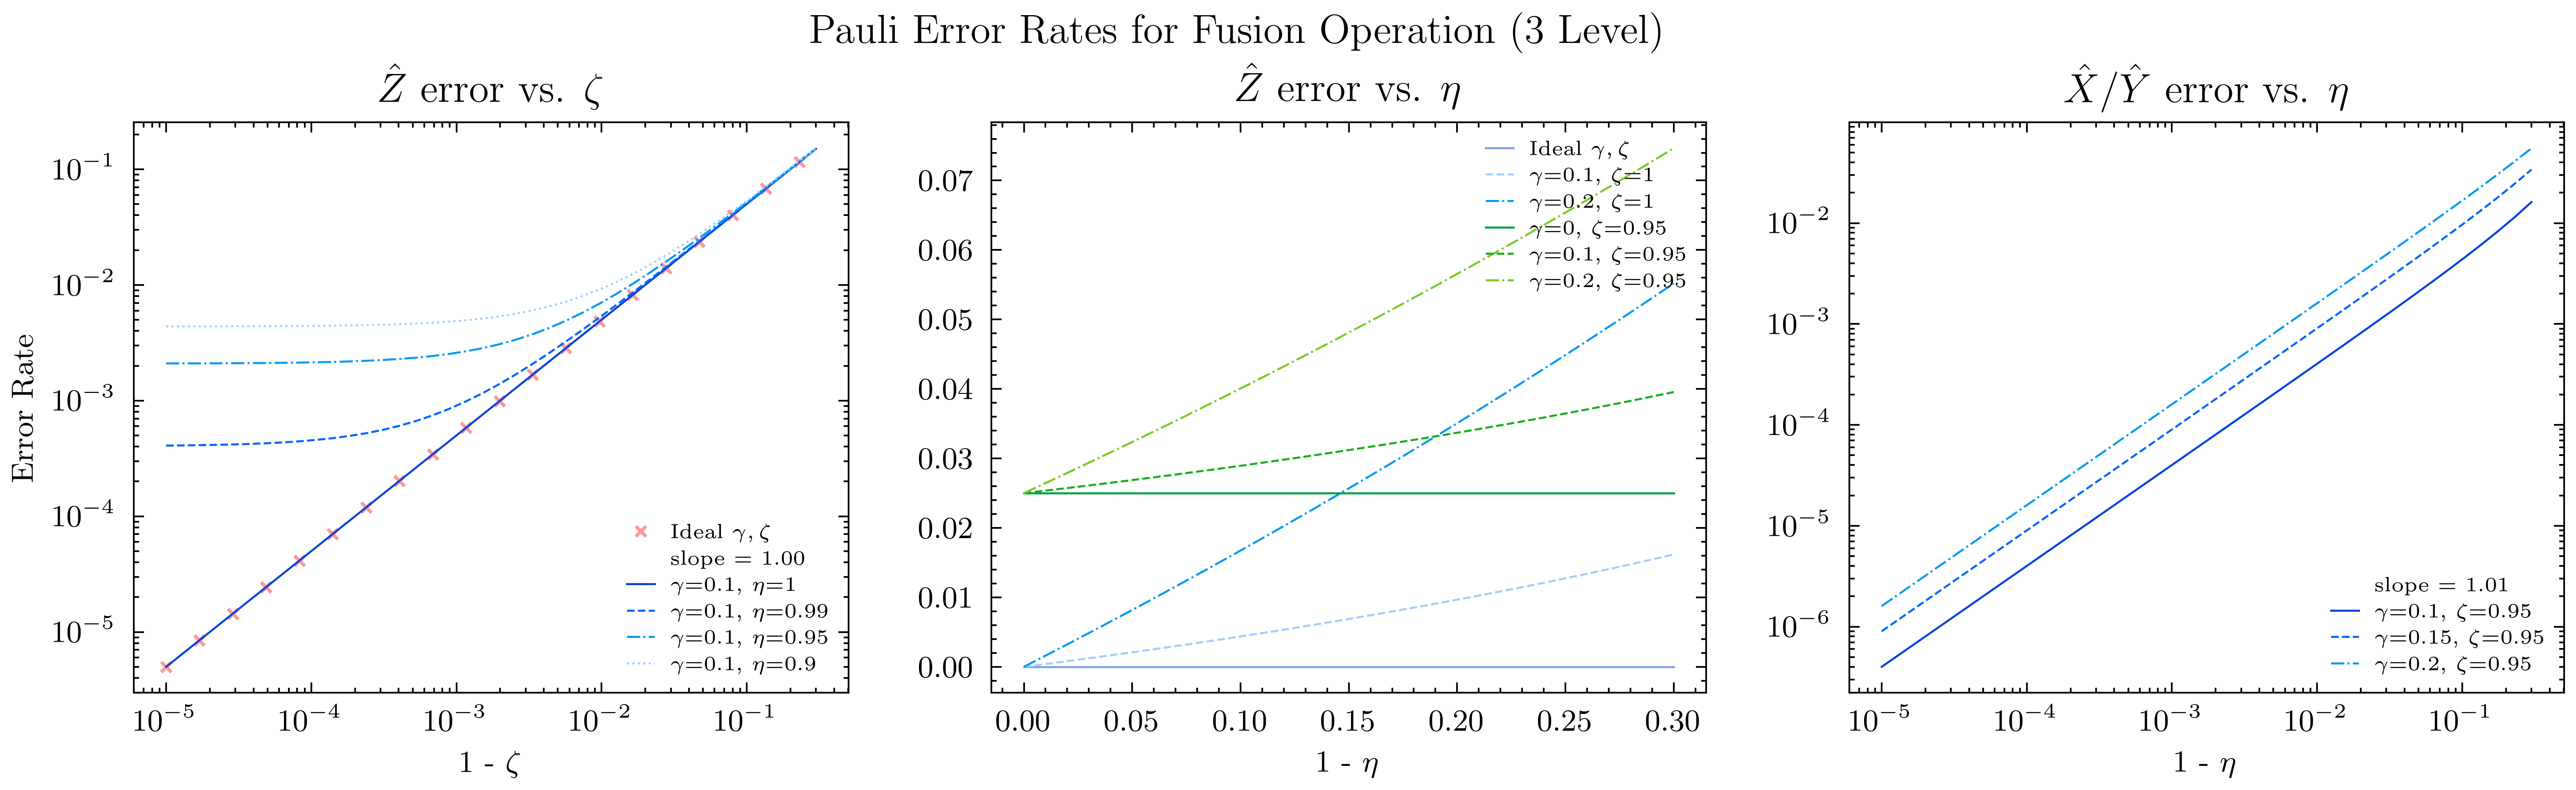

In [625]:
fig

In [626]:
fig.savefig('Fusion3.pdf', bbox_inches='tight')

## 4 Level

In [14]:
sum(pauli_err_fusion4(0.1, 0.99, 0.95))

np.float64(1.0000000000000002)

Text(0.5, 1.1, 'Pauli Error Rates for a Fusion Operation (4 Level)')

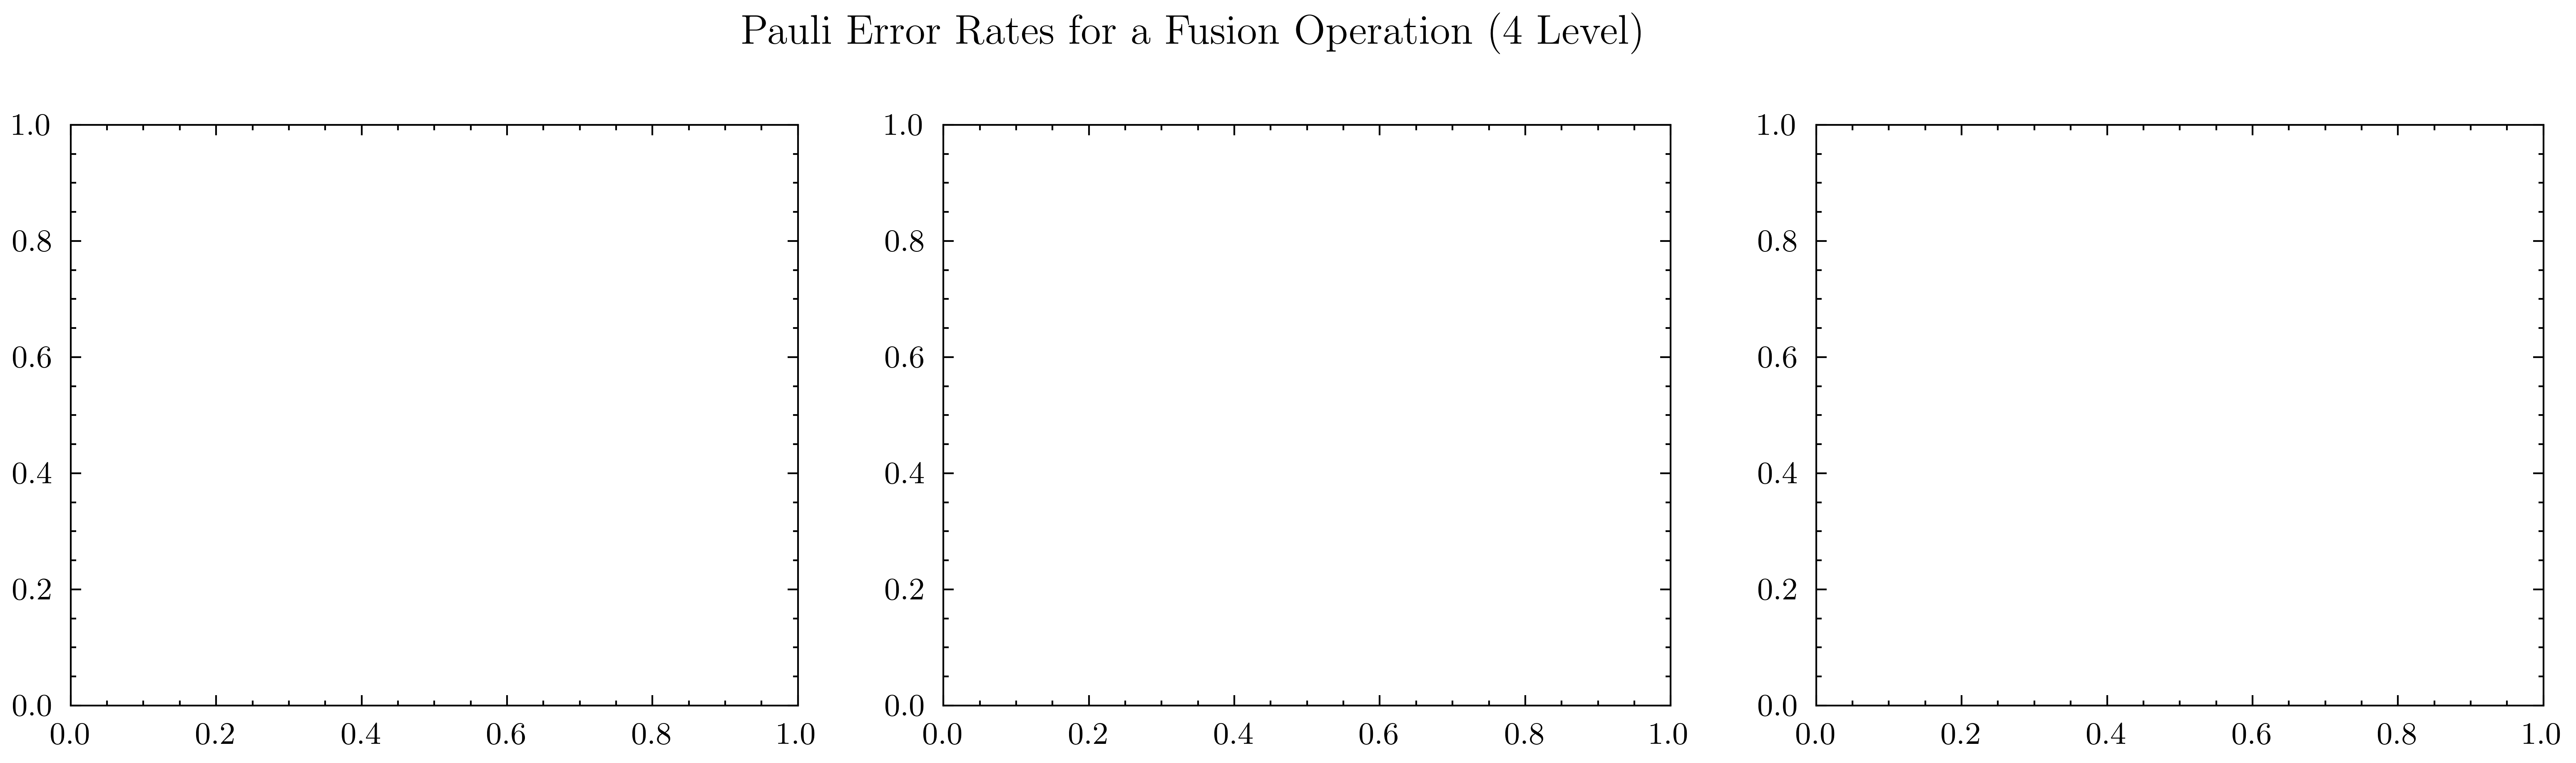

In [15]:
fig, p = plt.subplots(1,3, figsize=(12,3))
fig.suptitle('Pauli Error Rates for a Fusion Operation (4 Level)', y=1.1)

In [16]:
D_m_list = np.logspace(-5, np.log10(0.3), num=40)

err_list_id = []
err_list_1_1 = []
err_list_1_95 = []
err_list_1_9 = []
err_list_2_95 = []
err_list_2_9 = []

for i in D_m_list:
    D = 1 - i
    err_mat = pauli_err_fusion4(0, 1, D)
    err_list_id.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.1, 1, D)
    err_list_1_1.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.1, 0.95, D)
    err_list_1_95.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.1, 0.9, D)
    err_list_1_9.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.2, 0.95, D)
    err_list_2_95.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.2, 0.9, D)
    err_list_2_9.append(err_mat[0])

In [17]:
coeff = np.polyfit(np.log10(D_m_list)[1:10], np.log10(err_list_id)[1:10], 1)
coeff[0]

np.float64(0.9989287872129247)

In [18]:
p[0].loglog(D_m_list ,err_list_id, label='Ideal $\gamma, \zeta$', color='red', linestyle='', alpha=0.4, marker='x', ms=2)
p[0].loglog([],[], label=f'slope = {coeff_id[0]:.2f}', alpha=0)
p[0].loglog(D_m_list, err_list_1_1, label='$\gamma$=0.1, $\eta$=1', linestyle='-', color='xkcd:blue')
p[0].loglog(D_m_list, err_list_1_95, label='$\gamma$=0.1, $\eta$=0.95', linestyle='-.', color='xkcd:baby blue')
p[0].loglog(D_m_list, err_list_1_9, label='$\gamma$=0.1, $\eta$=0.9', linestyle='--', color='xkcd:azure')
p[0].loglog(D_m_list, err_list_2_95, label='$\gamma$=0.2, $\eta$=0.95', linestyle='-.', color='xkcd:emerald')
p[0].loglog(D_m_list, err_list_2_9, label='$\gamma$=0.2, $\eta$=0.9', linestyle='--', color='xkcd:green')
p[0].legend( frameon=False,  prop={'size': 6}, loc='lower right')
p[0].set_xlabel('1 - $\mathcal{D}$')
p[0].set_ylabel('Error Rate')
p[0].set_title(r'$\hat{X}$ error vs. $\mathcal{D}$')

NameError: name 'coeff_id' is not defined

In [19]:
# η_m_list = np.logspace(-5, np.log10(0.3), num=40)
η_m_list = np.linspace(0, 0.3, num=40)

err_list_id = []
err_list_1_1 = []
err_list_15_1 = []
err_list_2_1 = []
err_list_0_99 = []
err_list_1_99 = []
err_list_15_99 = []
err_list_2_99 = []
# err_list_2_95y = []

for i in η_m_list:
    η = 1 - i
    err_mat = pauli_err_fusion4(0, η, 1)
    err_list_id.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.1, η, 1)
    err_list_1_1.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.15, η, 1)
    err_list_15_1.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.2, η, 1)
    err_list_2_1.append(err_mat[0])
    err_mat = pauli_err_fusion4(0, η, 0.99)
    err_list_0_99.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.15, η, 0.99)
    err_list_15_99.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.1, η, 0.99)
    err_list_1_99.append(err_mat[0])
    err_mat = pauli_err_fusion4(0.2, η, 0.99)
    err_list_2_99.append(err_mat[0])
    # err_list_2_95y.append(err_mat[0])

In [20]:
# p.plot(η_m_list,err_list_id, label='Ideal $\gamma, \zeta$', color='xkcd:blue', linestyle='-', alpha=0.5, marker='o')
# p.loglog([],[], label=f'slope = {coeff[0]:.2f}', alpha=0)
p[1].plot(η_m_list,err_list_id, label='Ideal $\gamma, \mathcal{D}$', color='xkcd:deep blue', linestyle='-', alpha=0.5)
p[1].plot(η_m_list, err_list_1_1, label='$\gamma$=0.1, $\mathcal{D}$=1', linestyle='-.', color='xkcd:blue')
p[1].plot(η_m_list, err_list_15_1, label='$\gamma$=0.15, $\mathcal{D}$=1', linestyle='--', color='xkcd:azure')
p[1].plot(η_m_list, err_list_2_1, label='$\gamma$=0.2, $\mathcal{D}$=1', linestyle=':', color='xkcd:baby blue')

p[1].plot(η_m_list, err_list_0_99, label='$\gamma$=0.0, $\mathcal{D}$=0.99', linestyle='-', color='xkcd:emerald')
p[1].plot(η_m_list, err_list_1_99, label='$\gamma$=0.1, $\mathcal{D}$=0.99', linestyle='-.', color='xkcd:green')
p[1].plot(η_m_list, err_list_15_99, label='$\gamma$=0.15, $\mathcal{D}$=0.99', linestyle='--', color='xkcd:apple green')
p[1].plot(η_m_list, err_list_2_99, label='$\gamma$=0.2, $\mathcal{D}$=0.99', color='xkcd:yellowish green', linestyle=':')
p[1].legend(loc='upper right', prop={'size': 6}, facecolor='white', framealpha=0.9)
p[1].set_xlabel('1 - $\eta$')
# p[1].set_ylabel('Error Rate')  
p[1].set_title(r'$\hat{X}$ error vs. $\eta$')

Text(0.5, 1.0, '$\\hat{X}$ error vs. $\\eta$')

In [21]:
η_m_list = np.logspace(-5, np.log10(0.3), num=40)
# η_m_list = np.linspace(0, 0.3, num=40)

err_list_id = []
err_list_0_99 = []
err_list_0_95 = []

err_list_1_1 = []
err_list_1_99 = []
err_list_1_95 = []

err_list_2_1 = []
err_list_2_99 = []
err_list_2_95 = []

for i in η_m_list:
    η = 1 - i
    err_mat = pauli_err_fusion4(0, η, 1)
    err_list_id.append(err_mat[1])
    err_mat = pauli_err_fusion4(0, η, 0.99)
    err_list_0_99.append(err_mat[1])
    err_mat = pauli_err_fusion4(0, η, 0.95)
    err_list_0_95.append(err_mat[1])
    err_mat = pauli_err_fusion4(0.1, η, 1)
    err_list_1_1.append(err_mat[1])
    err_mat = pauli_err_fusion4(0.1, η, 0.99)
    err_list_1_99.append(err_mat[1])
    err_mat = pauli_err_fusion4(0.1, η, 0.95)
    err_list_1_95.append(err_mat[1])
    err_mat = pauli_err_fusion4(0.2, η, 1)
    err_list_2_1.append(err_mat[1])
    err_mat = pauli_err_fusion4(0.2, η, 0.99)
    err_list_2_99.append(err_mat[1])
    err_mat = pauli_err_fusion4(0.2, η, 0.95)
    err_list_2_95.append(err_mat[1])

In [22]:
coeff = np.polyfit(np.log10(η_m_list), np.log10(err_list_1_95), 1)
coeff[0]

/var/folders/s9/whvhj6gs5cx001kw71n2wfqr0000gq/T/ipykernel_7651/2584545490.py:1: RuntimeWarning: invalid value encountered in log10
  coeff = np.polyfit(np.log10(η_m_list), np.log10(err_list_1_95), 1)


np.float64(nan)

In [23]:
# p.plot(η_m_list,err_list_id, label='Ideal $\gamma, \zeta$', color='xkcd:blue', linestyle='-', alpha=0.5, marker='o')
p[2].loglog([],[], label=f'slope = {coeff[0]:.2f}', alpha=0)
# p.plot(η_m_list,err_list_id, label='Ideal $\gamma, \zeta$', color='xkcd:blue', linestyle='-', alpha=0.5)
p[2].loglog(η_m_list, err_list_1_1, label='$\gamma$=0.1, $\mathcal{D}$=1', linestyle='-', color='xkcd:deep blue')
p[2].loglog(η_m_list, err_list_1_99, label='$\gamma$=0.1, $\mathcal{D}$=0.99', linestyle='-.', color='xkcd:blue')
p[2].loglog(η_m_list, err_list_1_95, label='$\gamma$=0.1, $\mathcal{D}$=0.95', linestyle='--', color='xkcd:azure')

p[2].loglog(η_m_list, err_list_2_1, label='$\gamma$=0.2, $\mathcal{D}$=1', linestyle='-', color='xkcd:emerald')
p[2].loglog(η_m_list, err_list_2_99, label='$\gamma$=0.2, $\mathcal{D}$=0.99', linestyle='-.', color='xkcd:green')
p[2].loglog(η_m_list, err_list_2_95, label='$\gamma$=0.2, $\mathcal{D}$=0.95', linestyle='--', color='xkcd:apple green')
p[2].legend(loc='lower right', frameon=False,  prop={'size': 6})
# p[2].set_xscale('log')
# p[2].set_yscale('log')
p[2].set_xlabel('1 - $\eta$')
# p[2].set_ylabel('Error Rate')  
p[2].set_title(r'$\hat{Y} / \hat{Z}$ error vs. $\eta$')

Text(0.5, 1.0, '$\\hat{Y} / \\hat{Z}$ error vs. $\\eta$')

/opt/miniconda3/envs/ErrFBQC/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


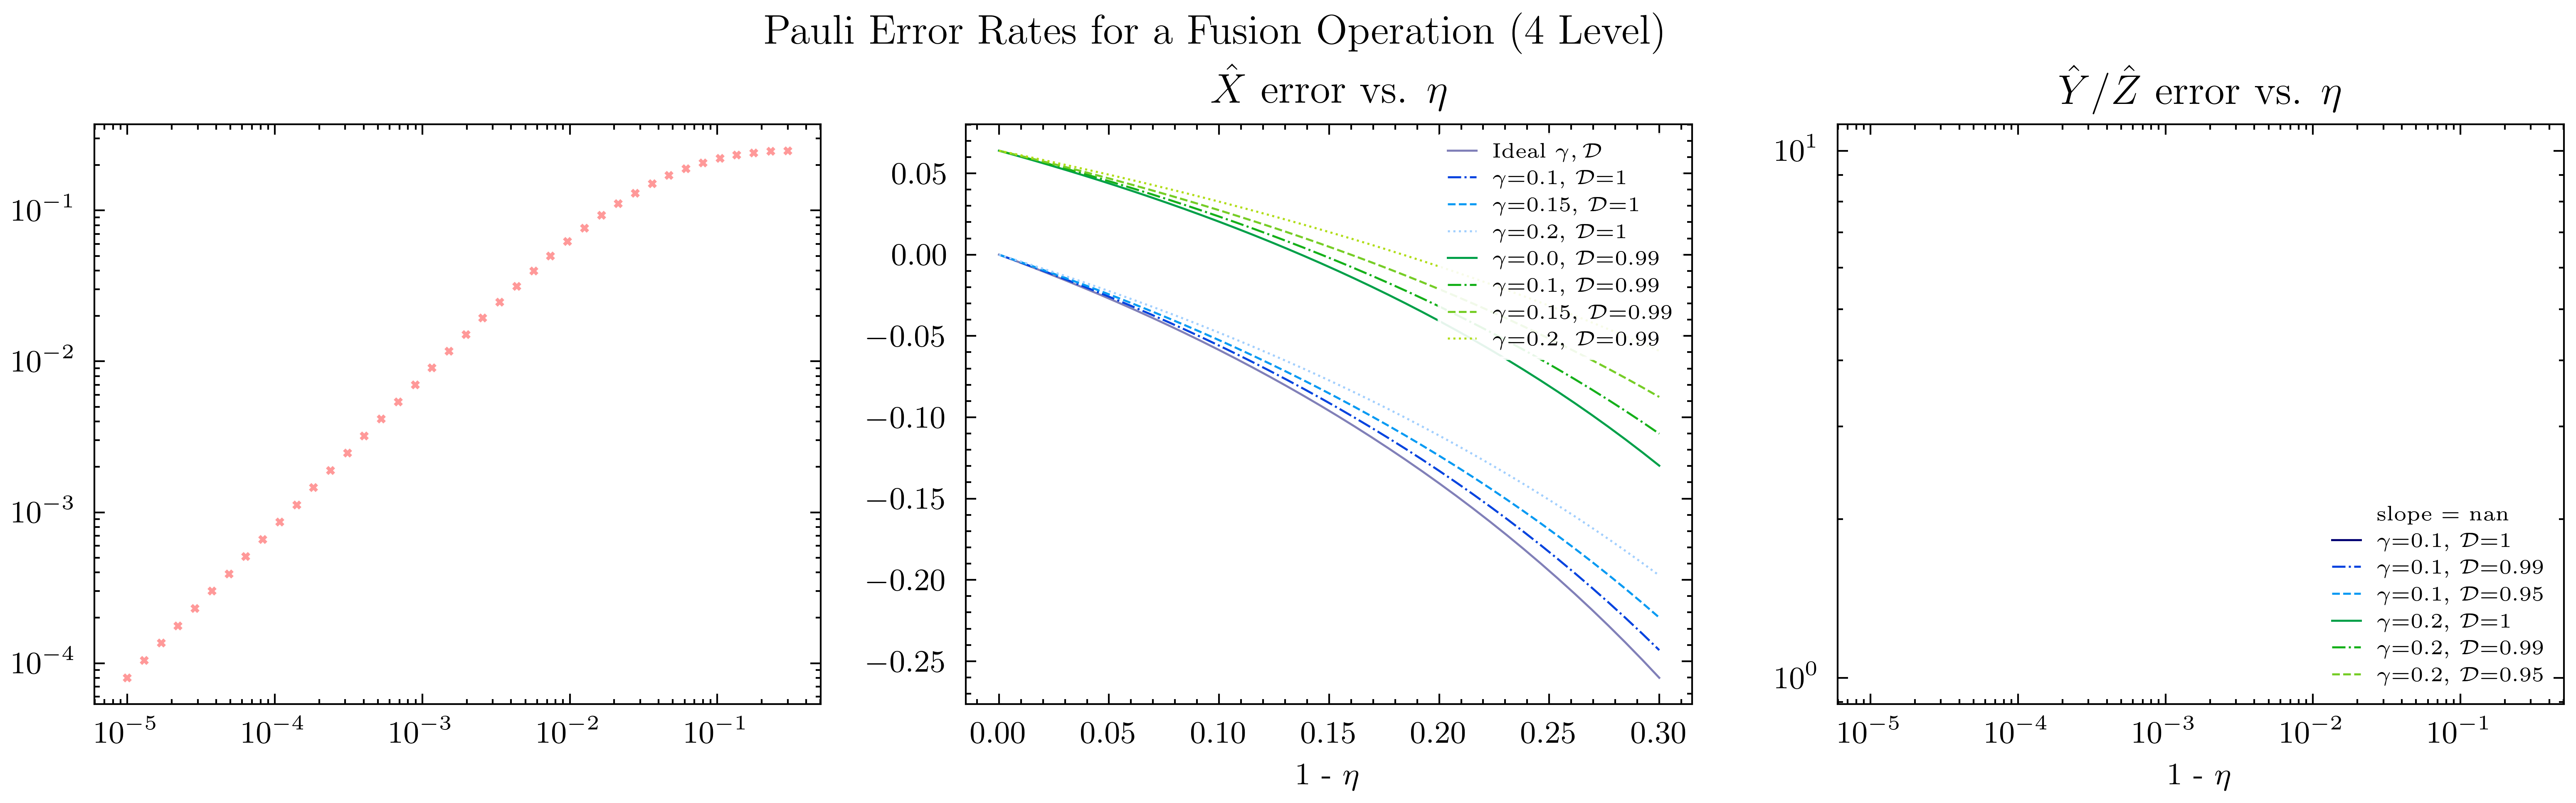

In [24]:
fig

In [638]:
fig.savefig('Fusion4.pdf', bbox_inches='tight')